In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
df = pd.read_csv('../codes/data_syn.csv')

/var/folders/v6/43nstwv52771z0q7sjpfqzv00000gn/T/ipykernel_58522/2994520675.py:12: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  plt.tight_layout()
/Users/kayadetunji/anaconda3/envs/kaymacmini/lib/python3.9/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


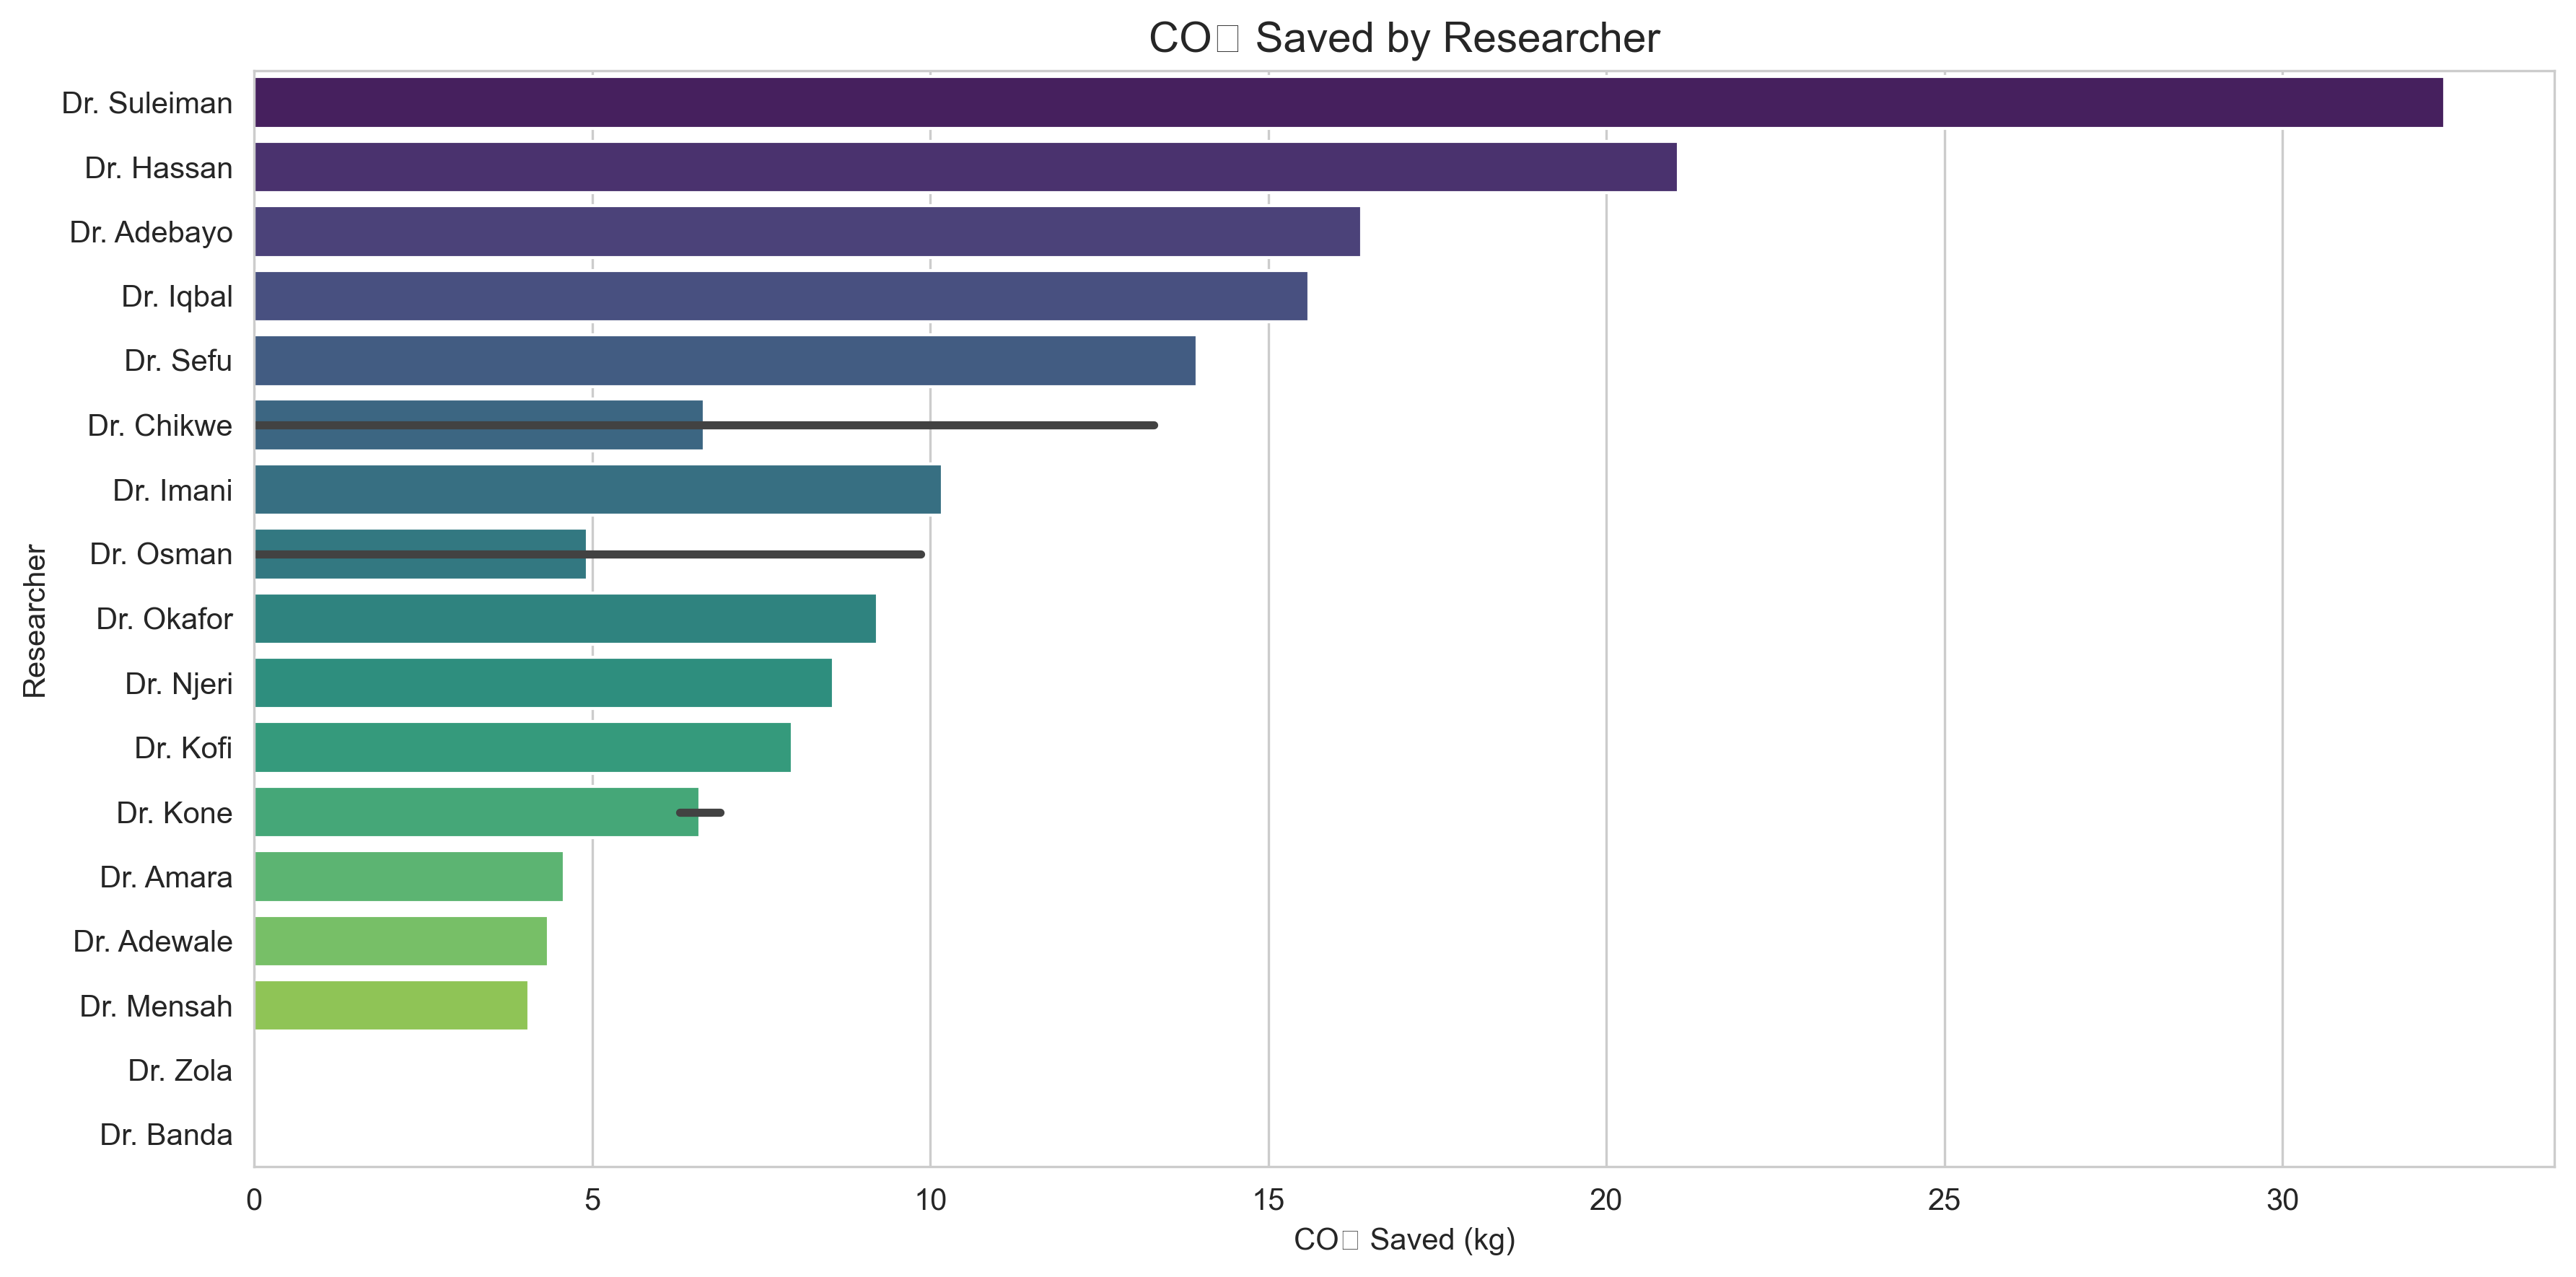

In [ ]:
# Set style
plt.rcParams.update({'axes.titlesize': 14, 'axes.labelsize': 12})
sns.set_style("whitegrid")

# 1. CO2 Saved by Researcher
plt.figure(figsize=(12, 6), dpi=300)
top_co2 = df.sort_values(by="CO2 Saved (kg)", ascending=False)
sns.barplot(x="CO2 Saved (kg)", y="Researcher", data=top_co2, palette="viridis")
plt.title("CO₂ Saved by Researcher")
plt.xlabel("CO₂ Saved (kg)")
plt.ylabel("Researcher")
plt.tight_layout()
plt.show()


/var/folders/v6/43nstwv52771z0q7sjpfqzv00000gn/T/ipykernel_58522/1864859626.py:8: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  plt.tight_layout()
/var/folders/v6/43nstwv52771z0q7sjpfqzv00000gn/T/ipykernel_58522/1864859626.py:8: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from current font.
  plt.tight_layout()
/Users/kayadetunji/anaconda3/envs/kaymacmini/lib/python3.9/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kayadetunji/anaconda3/envs/kaymacmini/lib/python3.9/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


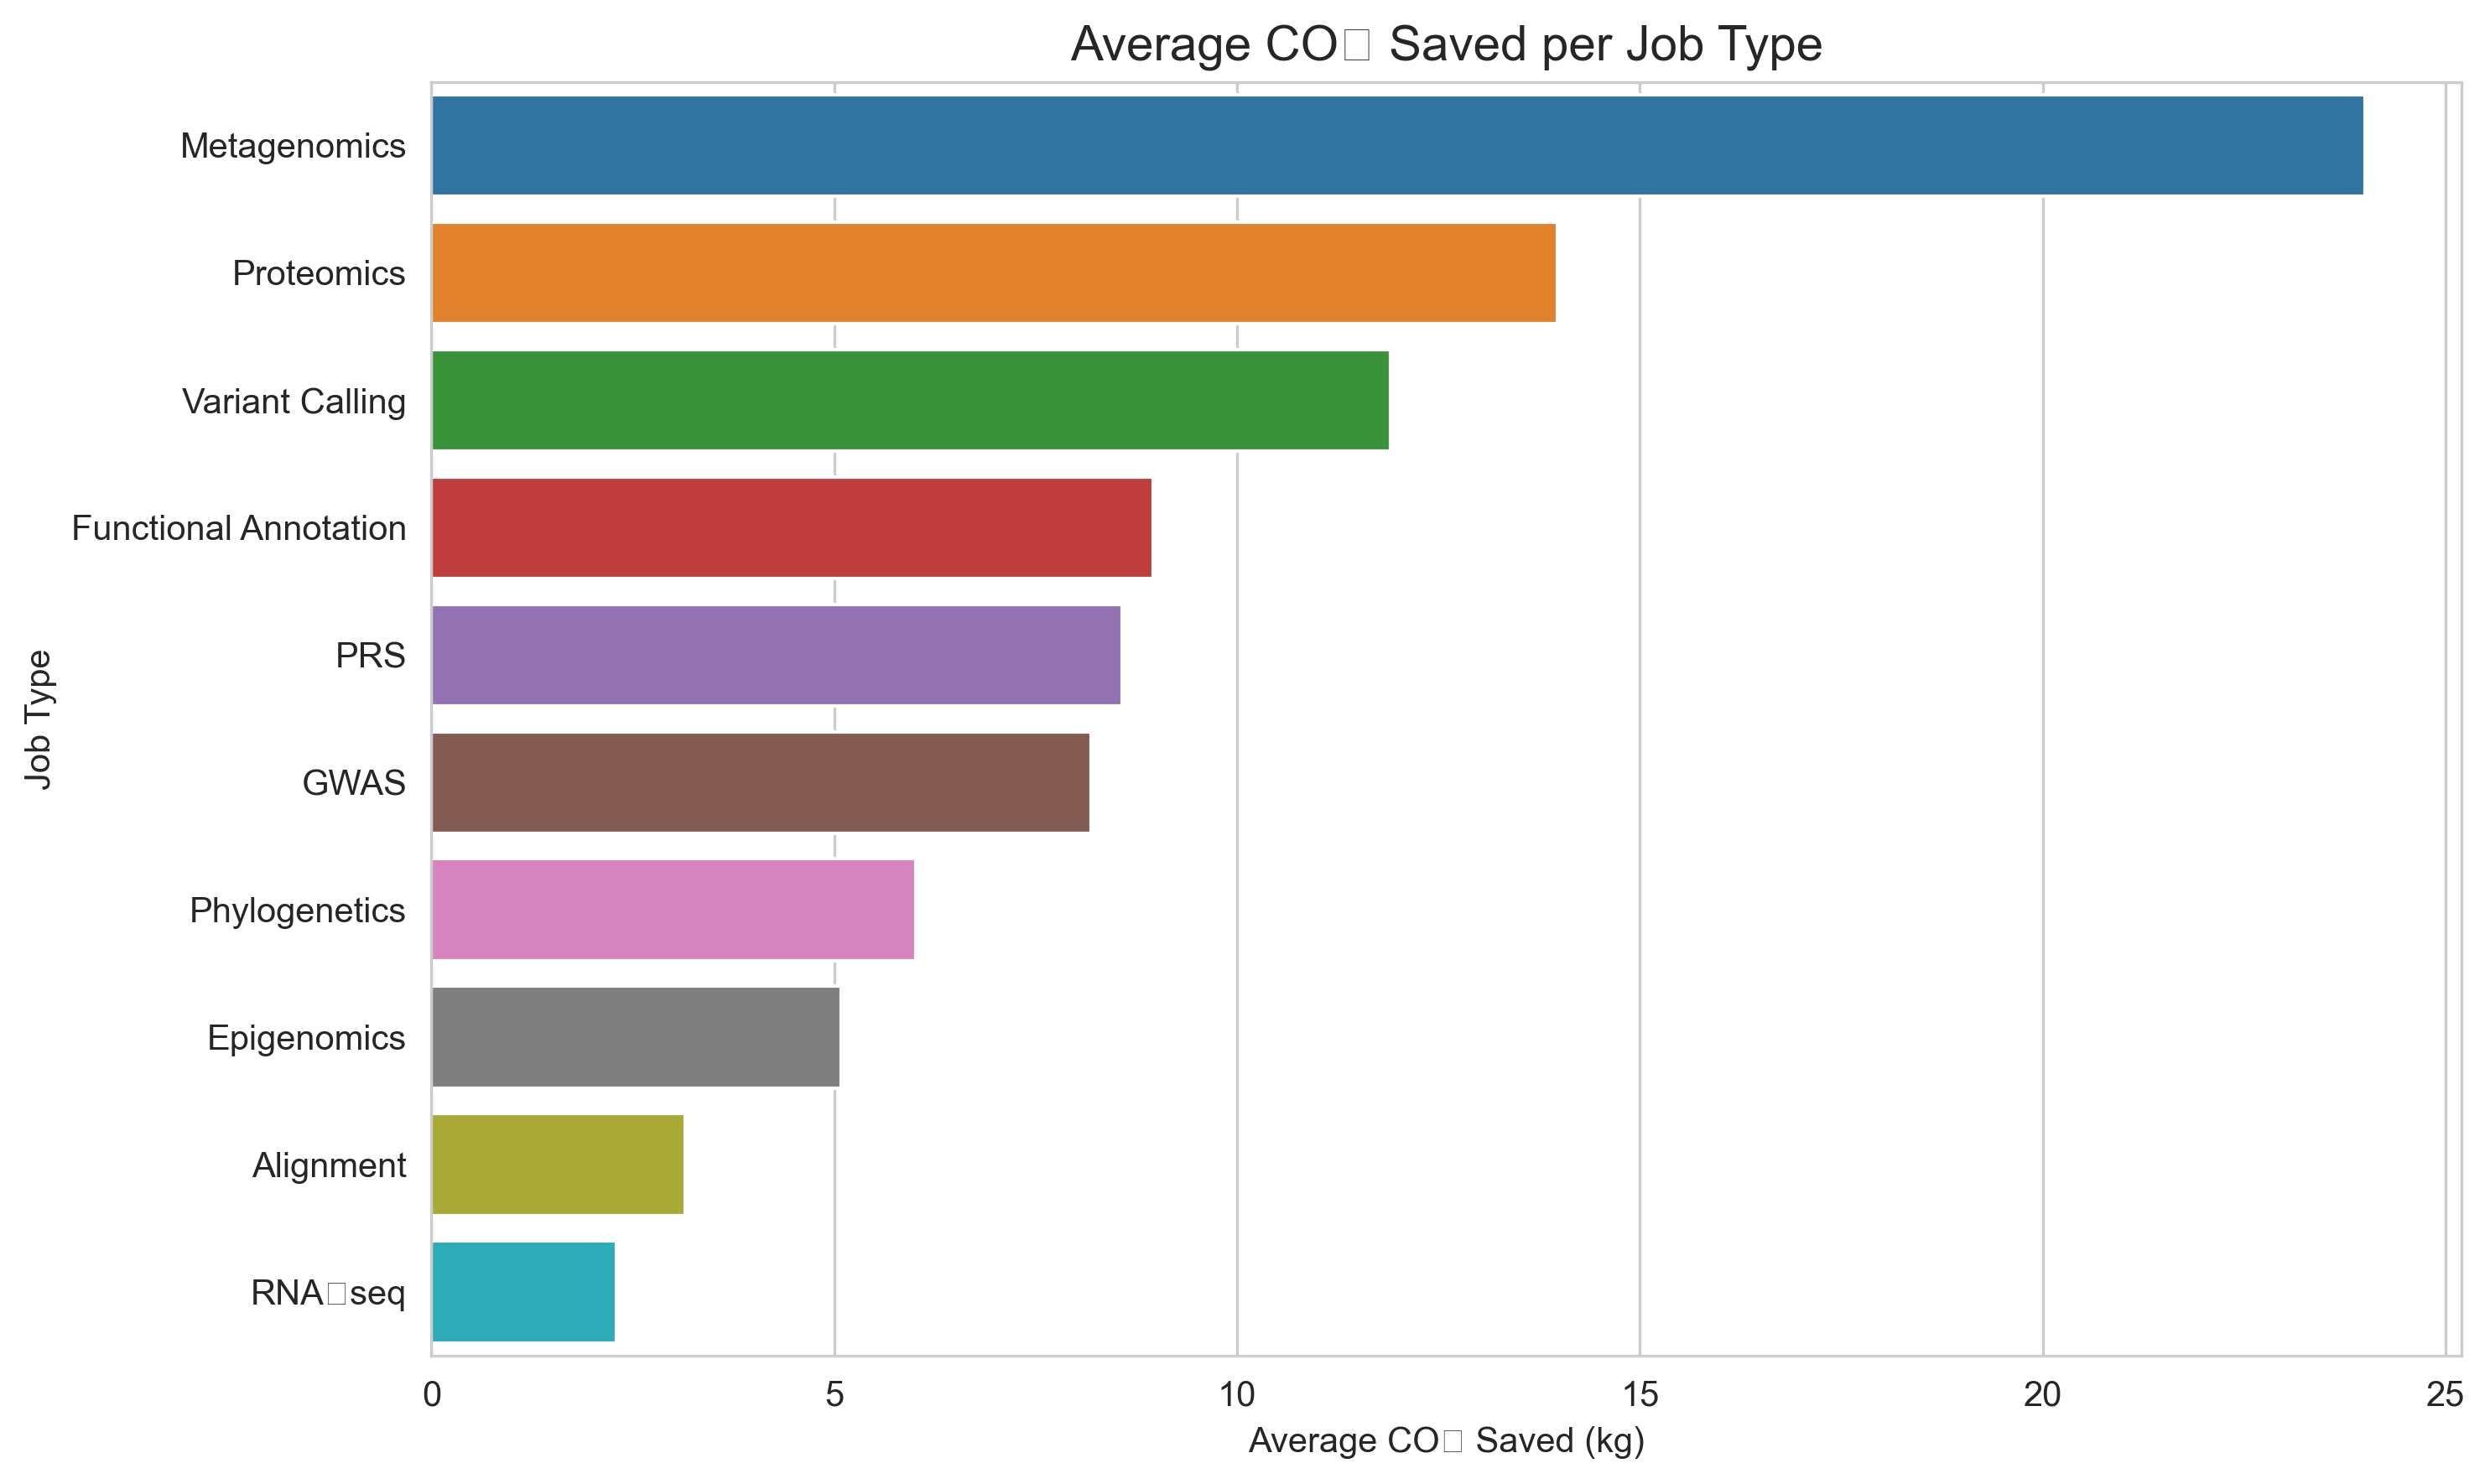

In [21]:

# 2. Avg CO2 Saved per Job Type
plt.figure(figsize=(10, 6), dpi=300)
job_co2 = df.groupby("Job Type")["CO2 Saved (kg)"].mean().sort_values(ascending=False)
sns.barplot(x=job_co2.values, y=job_co2.index)
plt.title("Average CO₂ Saved per Job Type")
plt.xlabel("Average CO₂ Saved (kg)")
plt.ylabel("Job Type")
plt.tight_layout()
plt.show()


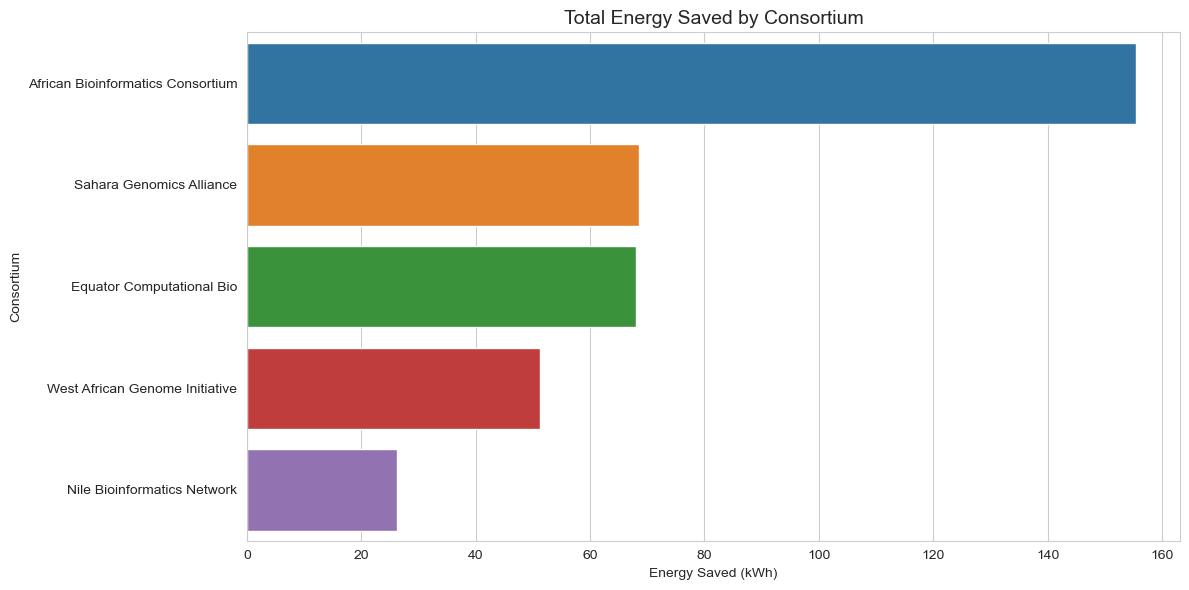

In [10]:

# 3. Energy Saved (Baseline - Optimized) by Consortium
df["Energy Saved (kWh)"] = df["Baseline Energy (kWh)"] - df["Optimized Energy (kWh)"]
plt.figure(figsize=(12, 6))
consortium_savings = df.groupby("Consortium")["Energy Saved (kWh)"].sum().sort_values(ascending=False)
sns.barplot(x=consortium_savings.values, y=consortium_savings.index)
plt.title("Total Energy Saved by Consortium")
plt.xlabel("Energy Saved (kWh)")
plt.ylabel("Consortium")
plt.tight_layout()
plt.show()


/var/folders/v6/43nstwv52771z0q7sjpfqzv00000gn/T/ipykernel_58522/2242971931.py:8: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  plt.tight_layout()
/var/folders/v6/43nstwv52771z0q7sjpfqzv00000gn/T/ipykernel_58522/2242971931.py:8: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from current font.
  plt.tight_layout()
/Users/kayadetunji/anaconda3/envs/kaymacmini/lib/python3.9/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kayadetunji/anaconda3/envs/kaymacmini/lib/python3.9/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


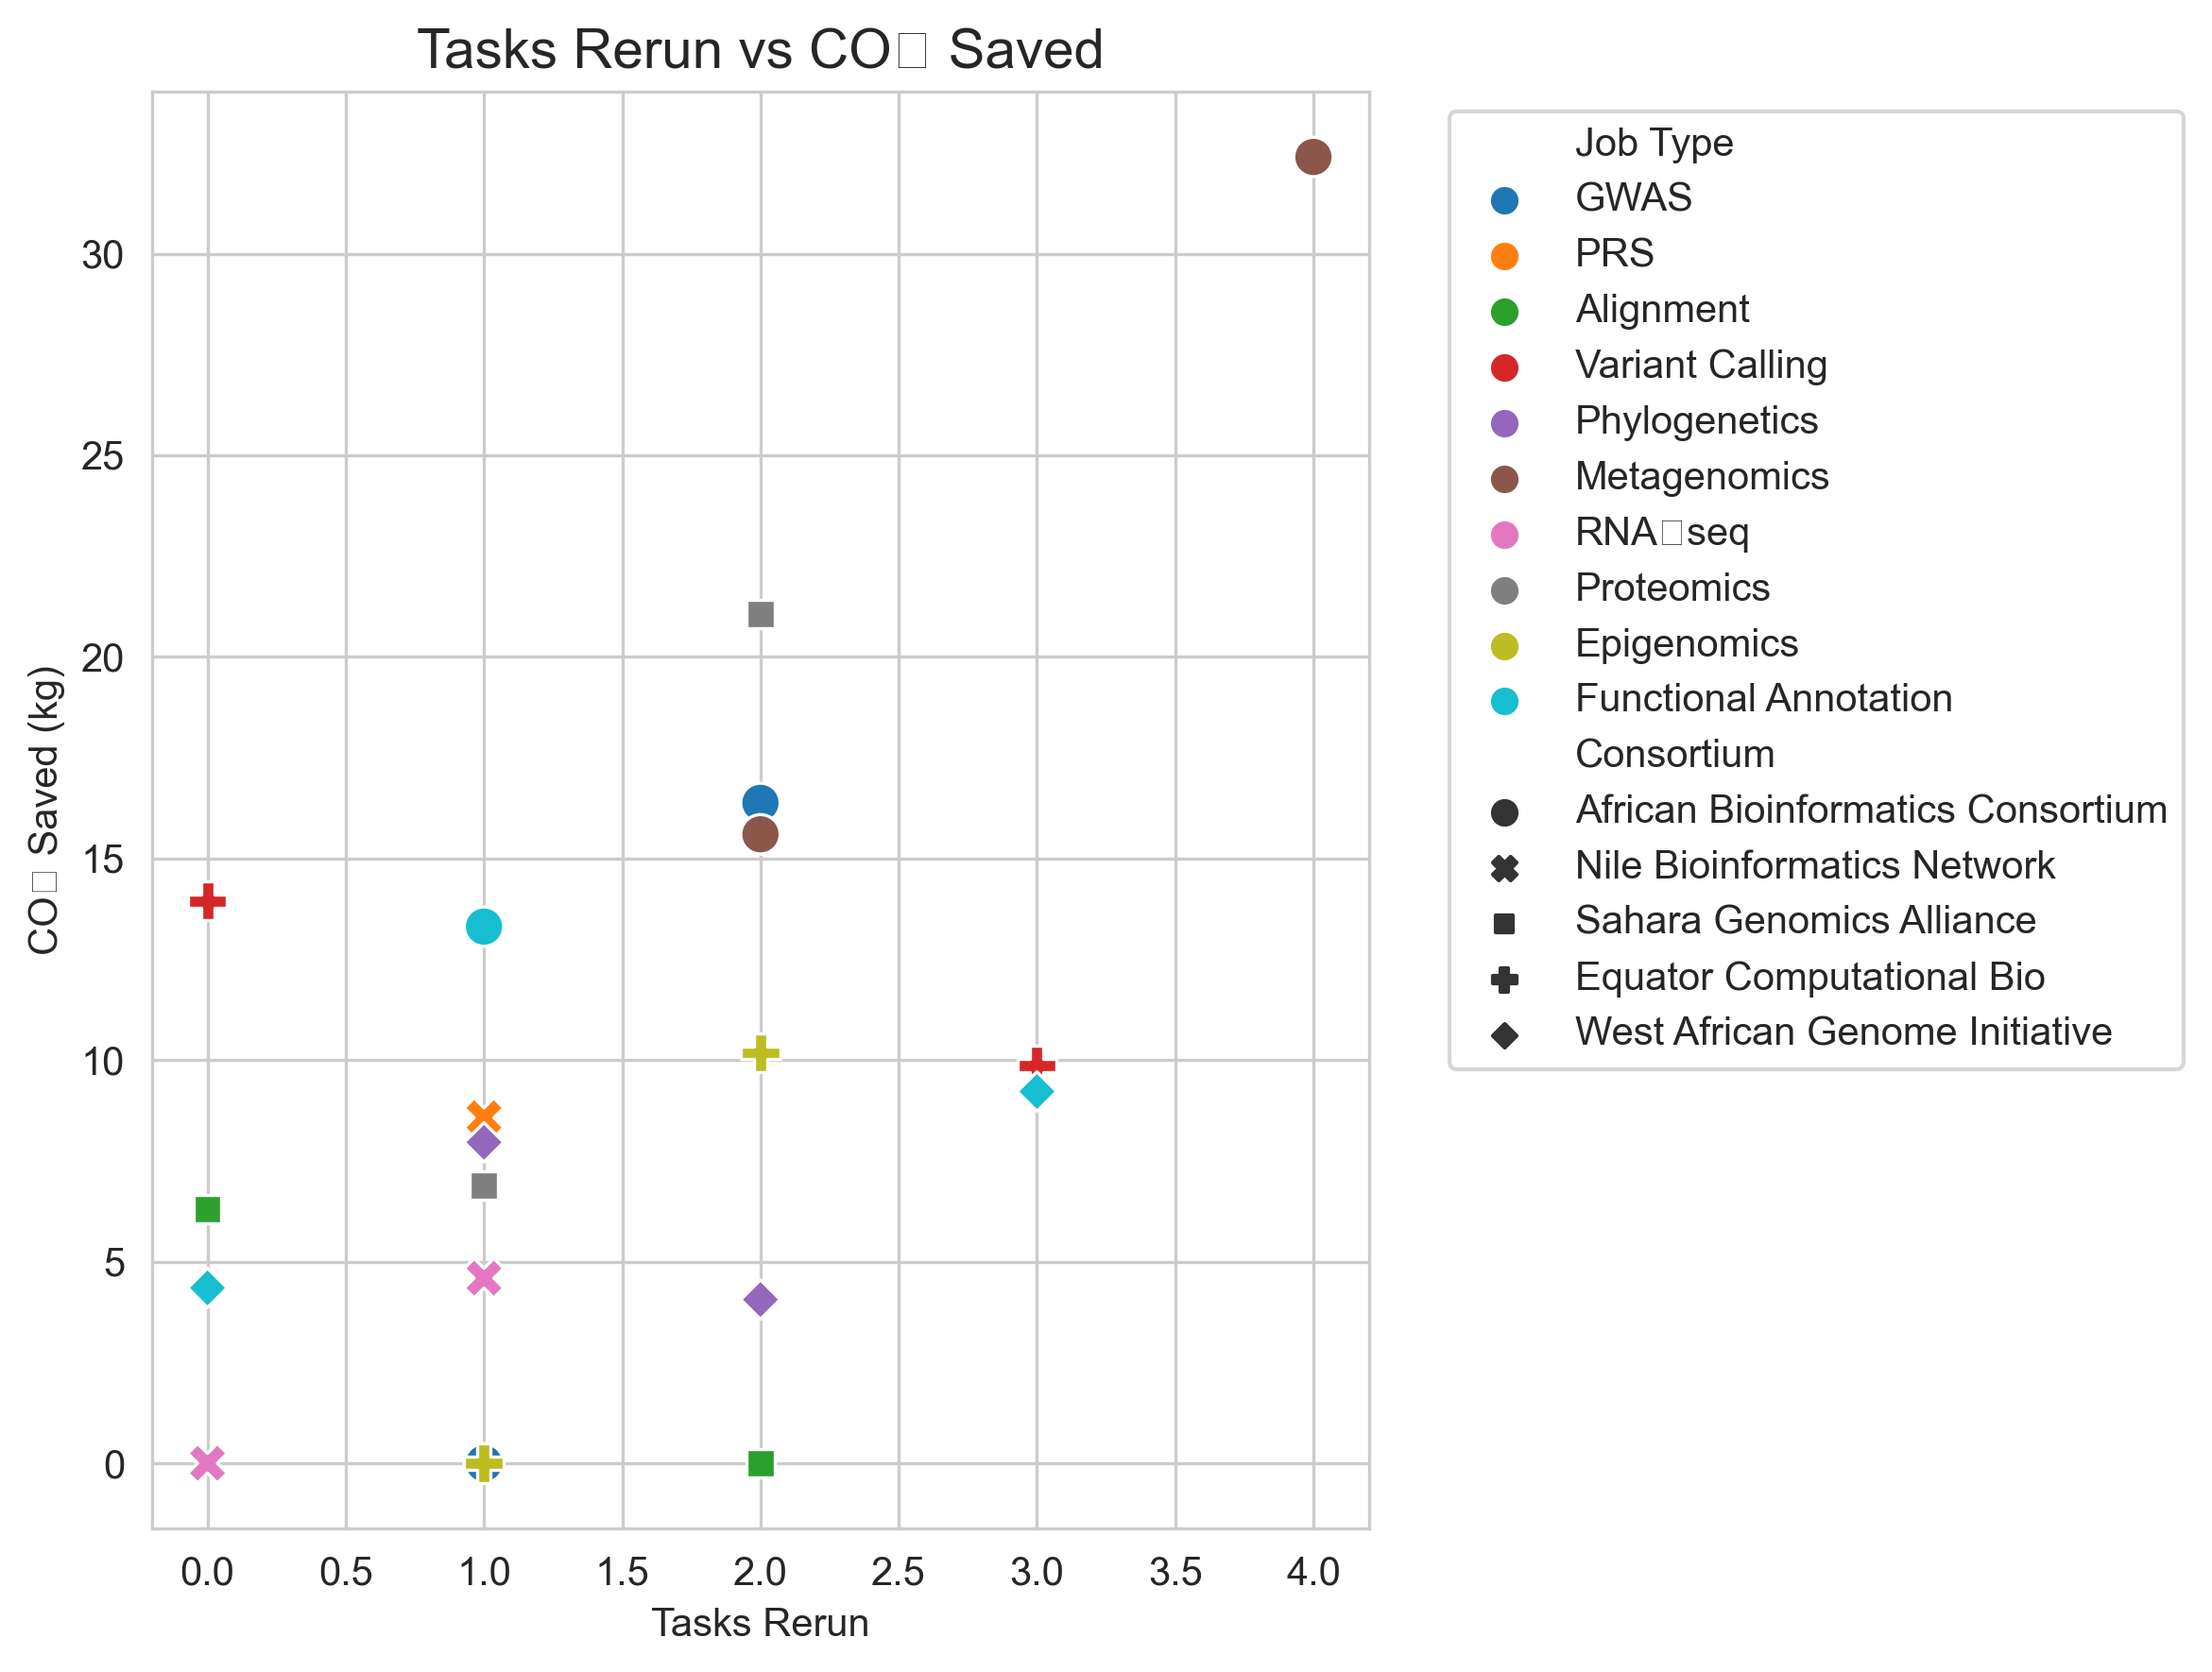

In [23]:

# 4. Correlation between Tasks Rerun and CO2 Saved
plt.figure(figsize=(8, 6), dpi=300)
sns.scatterplot(data=df, x="Tasks Rerun", y="CO2 Saved (kg)", hue="Job Type", style="Consortium", s=100)
plt.title("Tasks Rerun vs CO₂ Saved")
plt.xlabel("Tasks Rerun")
plt.ylabel("CO₂ Saved (kg)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


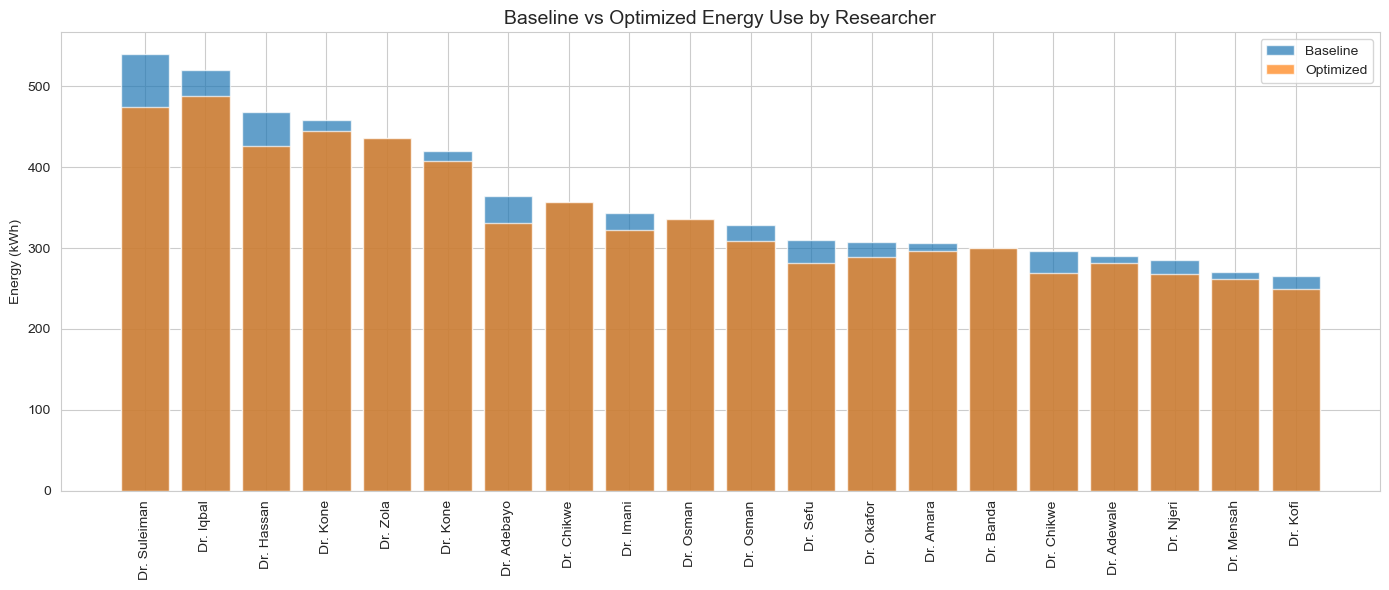

In [12]:

# 5. Baseline vs Optimized Energy Use by Researcher
plt.figure(figsize=(14, 6))
sorted_df = df.sort_values(by="Baseline Energy (kWh)", ascending=False)
x = range(len(sorted_df))
plt.bar(x, sorted_df["Baseline Energy (kWh)"], label='Baseline', alpha=0.7)
plt.bar(x, sorted_df["Optimized Energy (kWh)"], label='Optimized', alpha=0.7)
plt.xticks(x, sorted_df["Researcher"], rotation=90)
plt.ylabel("Energy (kWh)")
plt.title("Baseline vs Optimized Energy Use by Researcher")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
import statsmodels.api as sm

# Prepare features and target for regression
features = df[["Tasks Rerun", "Subtasks Delegated", "Runtime Increase (%)"]]
target = df["CO2 Saved (kg)"]

# Add constant for intercept
features = sm.add_constant(features)

# Fit linear regression model
model = sm.OLS(target, features).fit()
model_summary = model.summary()

model_summary.tables[1]  # Coefficients and significance table

,coef,std err,t,P>|t|,[0.025,0.975]
const,-2.2148,1.242,-1.783,0.093,-4.836,0.407
Tasks Rerun,1.3358,0.678,1.971,0.065,-0.094,2.766
Subtasks Delegated,0.2217,0.024,9.147,0.000,0.171,0.273
Runtime Increase (%),1.1086,0.121,9.147,0.000,0.853,1.364


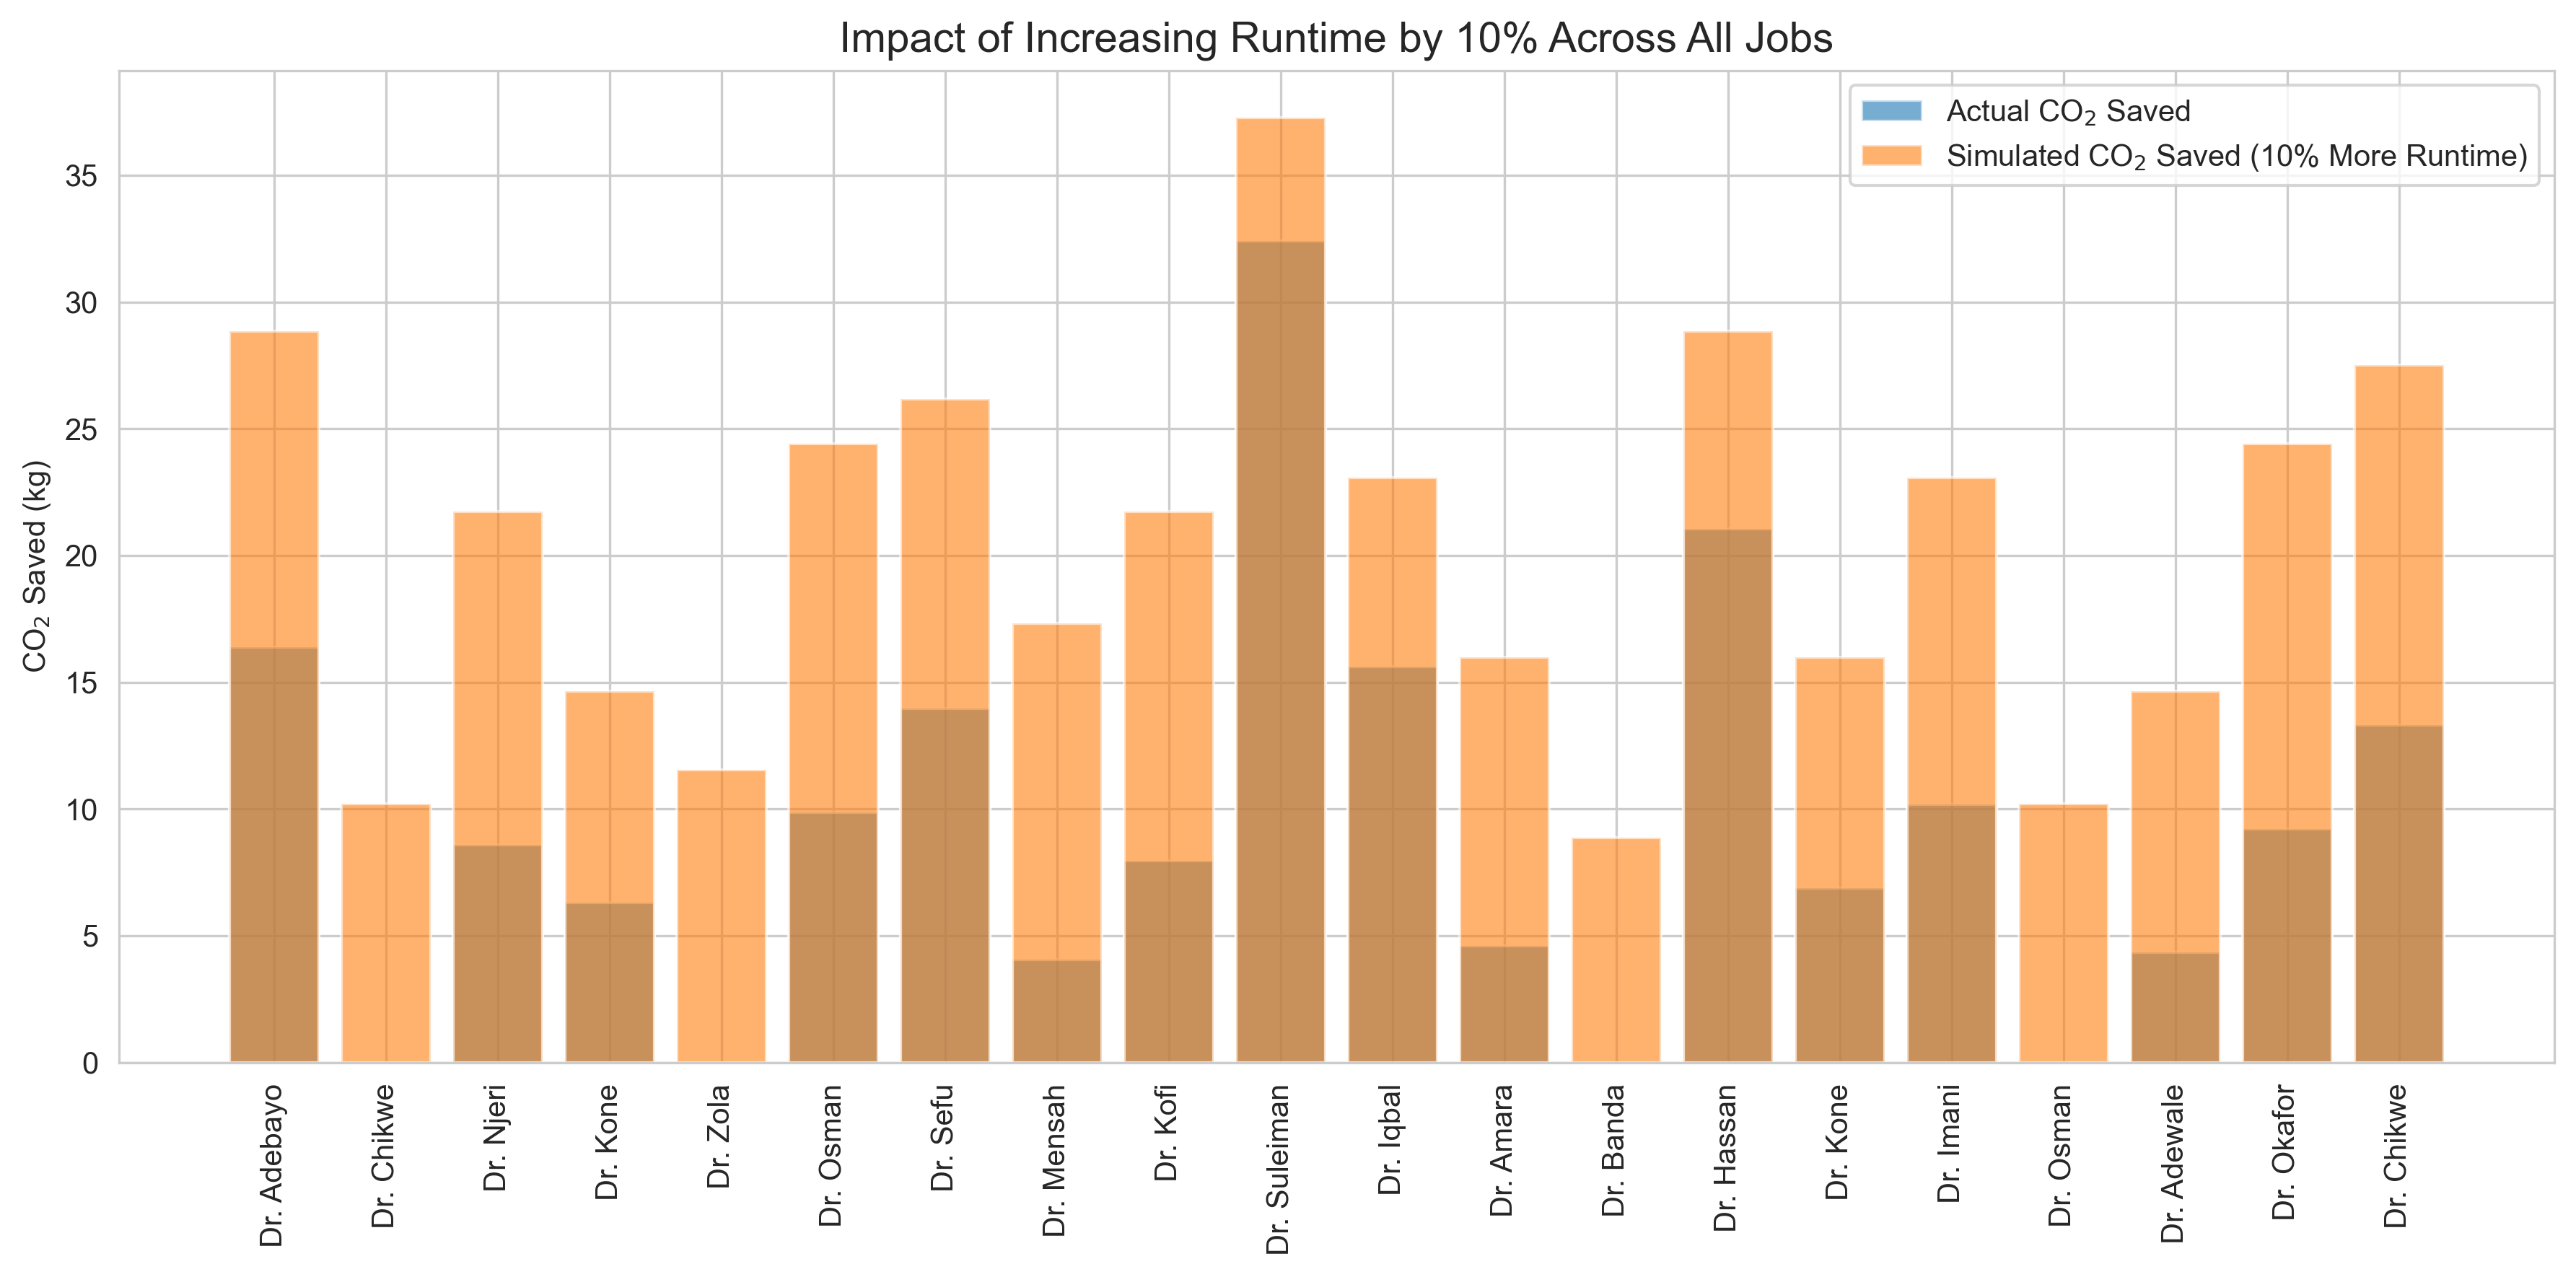

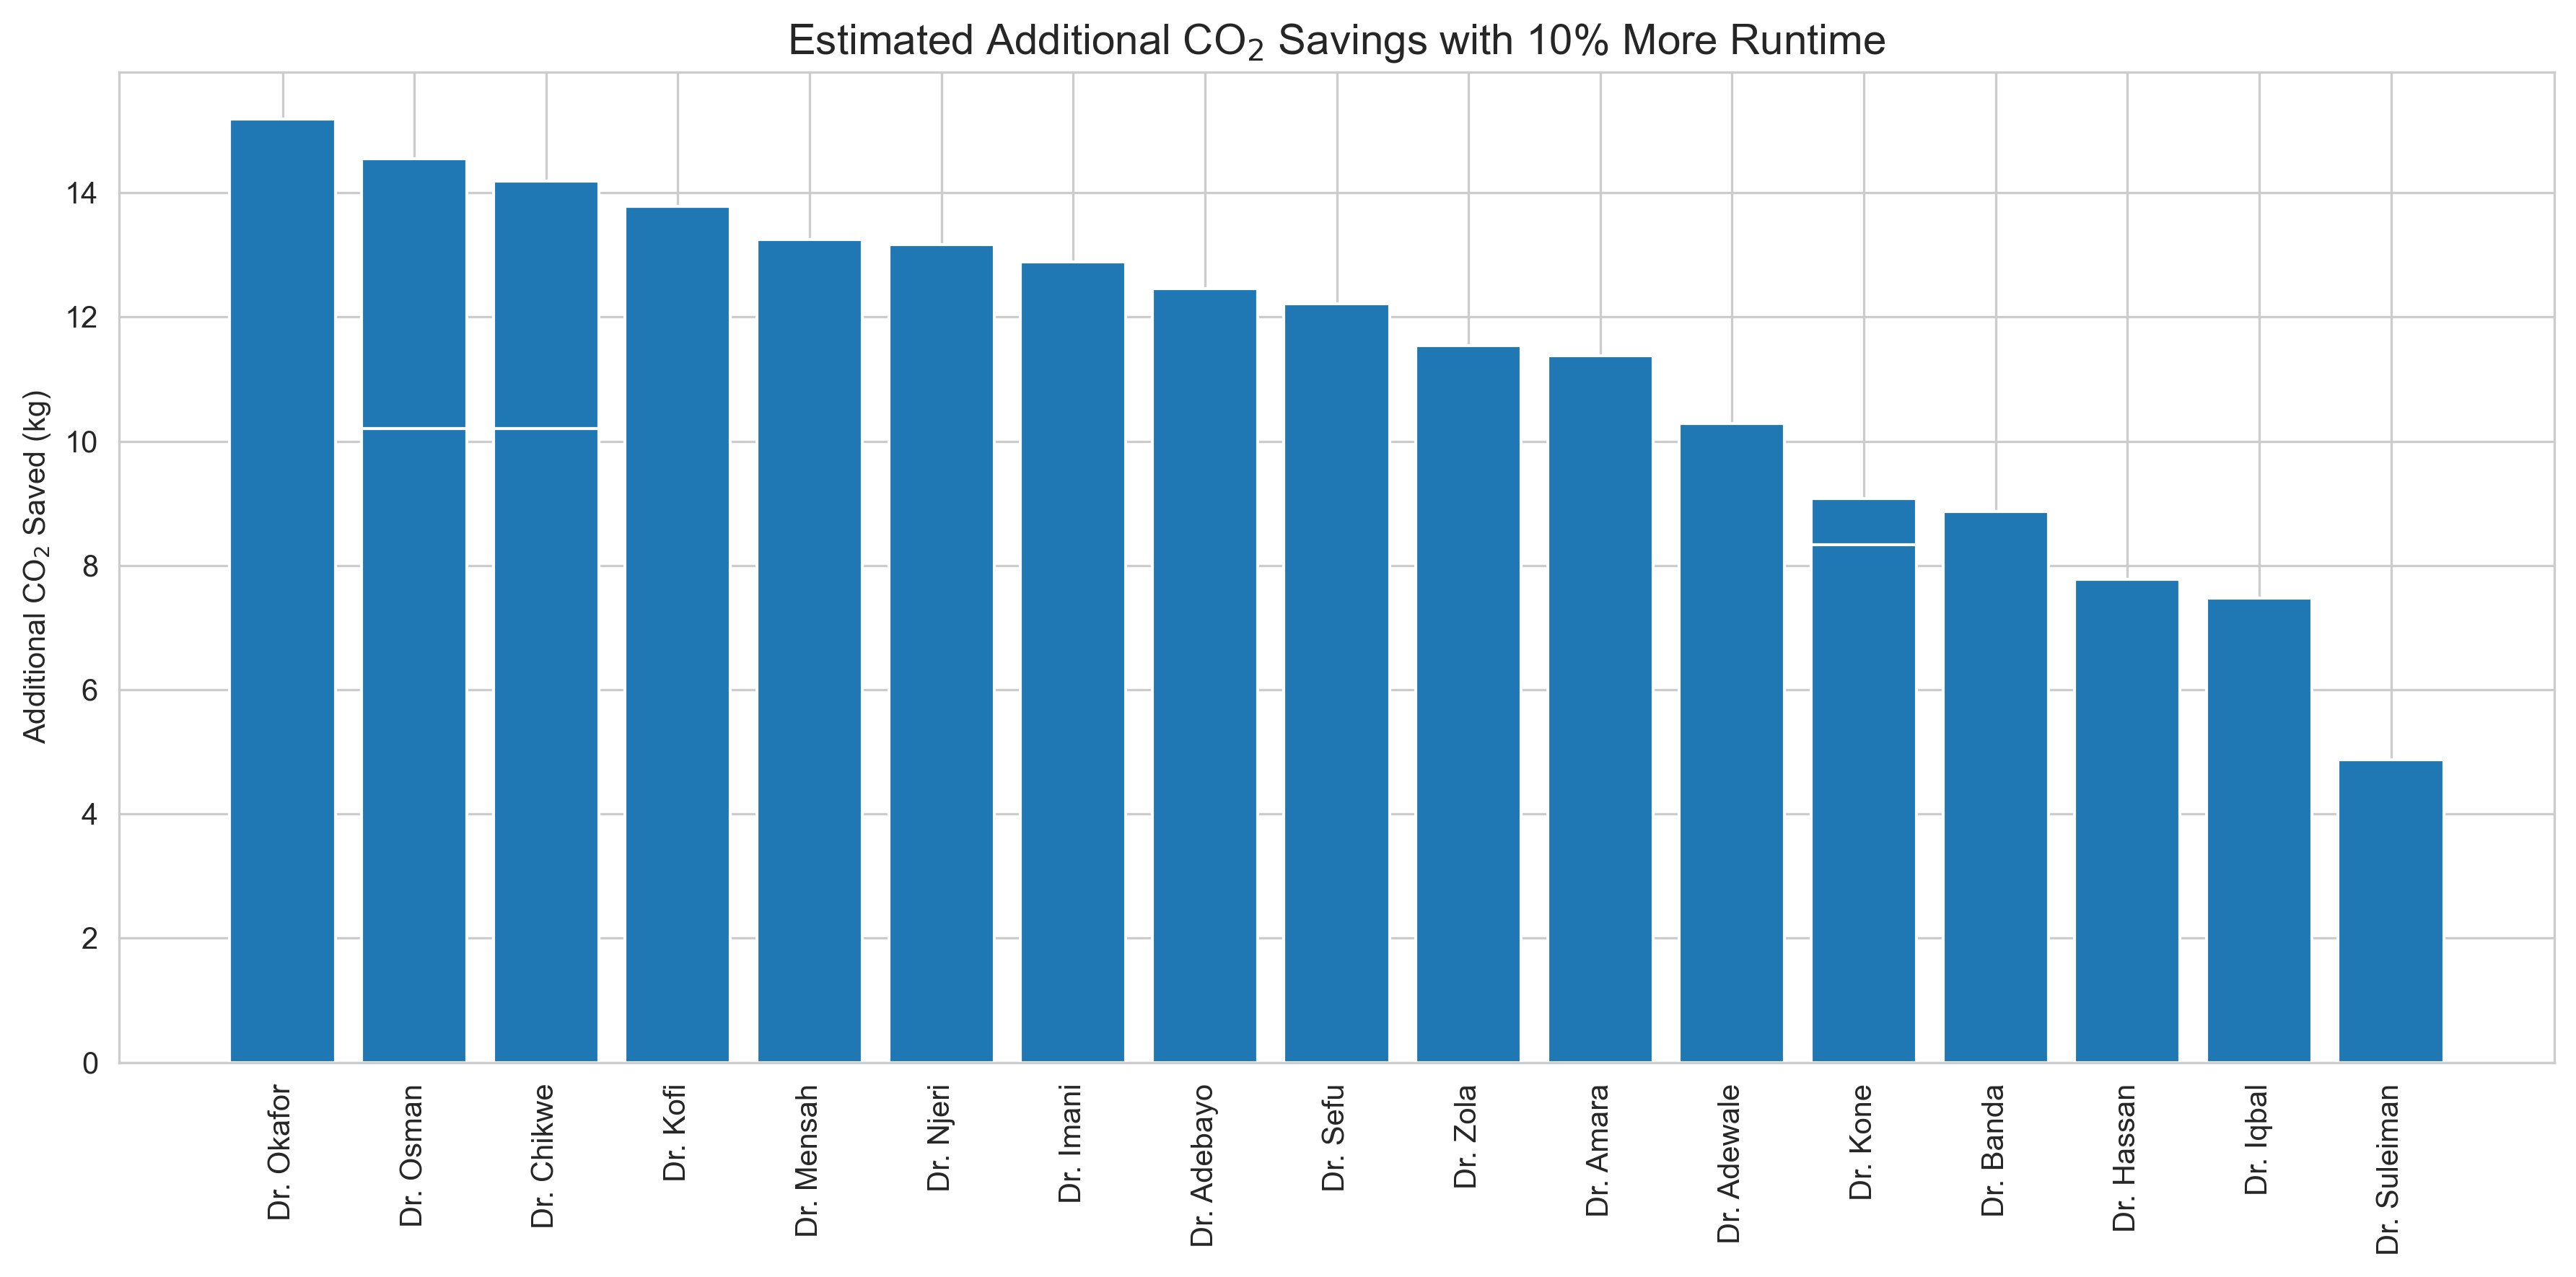

221.72026169706612

In [27]:
# Simulate a 10% increase in runtime across all jobs
# We'll use the model coefficients to estimate potential CO2 savings

# Clone original dataframe
df_simulated = df.copy()

# Increase runtime by 10%
df_simulated["Runtime Increase (%)"] += 10

# Predict new CO2 saved using the regression model
simulated_features = df_simulated[["Tasks Rerun", "Subtasks Delegated", "Runtime Increase (%)"]]
simulated_features = sm.add_constant(simulated_features)
df_simulated["Simulated CO2 Saved (kg)"] = model.predict(simulated_features)

# Compare actual vs simulated CO2 saved
df_simulated["Additional CO2 Saved (kg)"] = df_simulated["Simulated CO2 Saved (kg)"] - df["CO2 Saved (kg)"]

# Total additional CO2 saved across all jobs
total_additional_saved = df_simulated["Additional CO2 Saved (kg)"].sum()

# Visualize actual vs simulated CO2 saved
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6), dpi=300)
x = range(len(df_simulated))
plt.bar(x, df["CO2 Saved (kg)"], label='Actual CO$_2$ Saved', alpha=0.6)
plt.bar(x, df_simulated["Simulated CO2 Saved (kg)"], label='Simulated CO$_2$ Saved (10% More Runtime)', alpha=0.6)
plt.xticks(x, df["Researcher"], rotation=90)
plt.ylabel("CO$_2$ Saved (kg)")
plt.title("Impact of Increasing Runtime by 10% Across All Jobs")
plt.legend()
plt.tight_layout()
plt.show()

# Bar plot for additional CO2 savings from simulation
plt.figure(figsize=(12, 6), dpi=300)
df_simulated_sorted = df_simulated.sort_values(by="Additional CO2 Saved (kg)", ascending=False)
plt.bar(df_simulated_sorted["Researcher"], df_simulated_sorted["Additional CO2 Saved (kg)"])
plt.xticks(rotation=90)
plt.ylabel("Additional CO$_2$ Saved (kg)")
plt.title("Estimated Additional CO$_2$ Savings with 10% More Runtime")
plt.tight_layout()
plt.show()

total_additional_saved

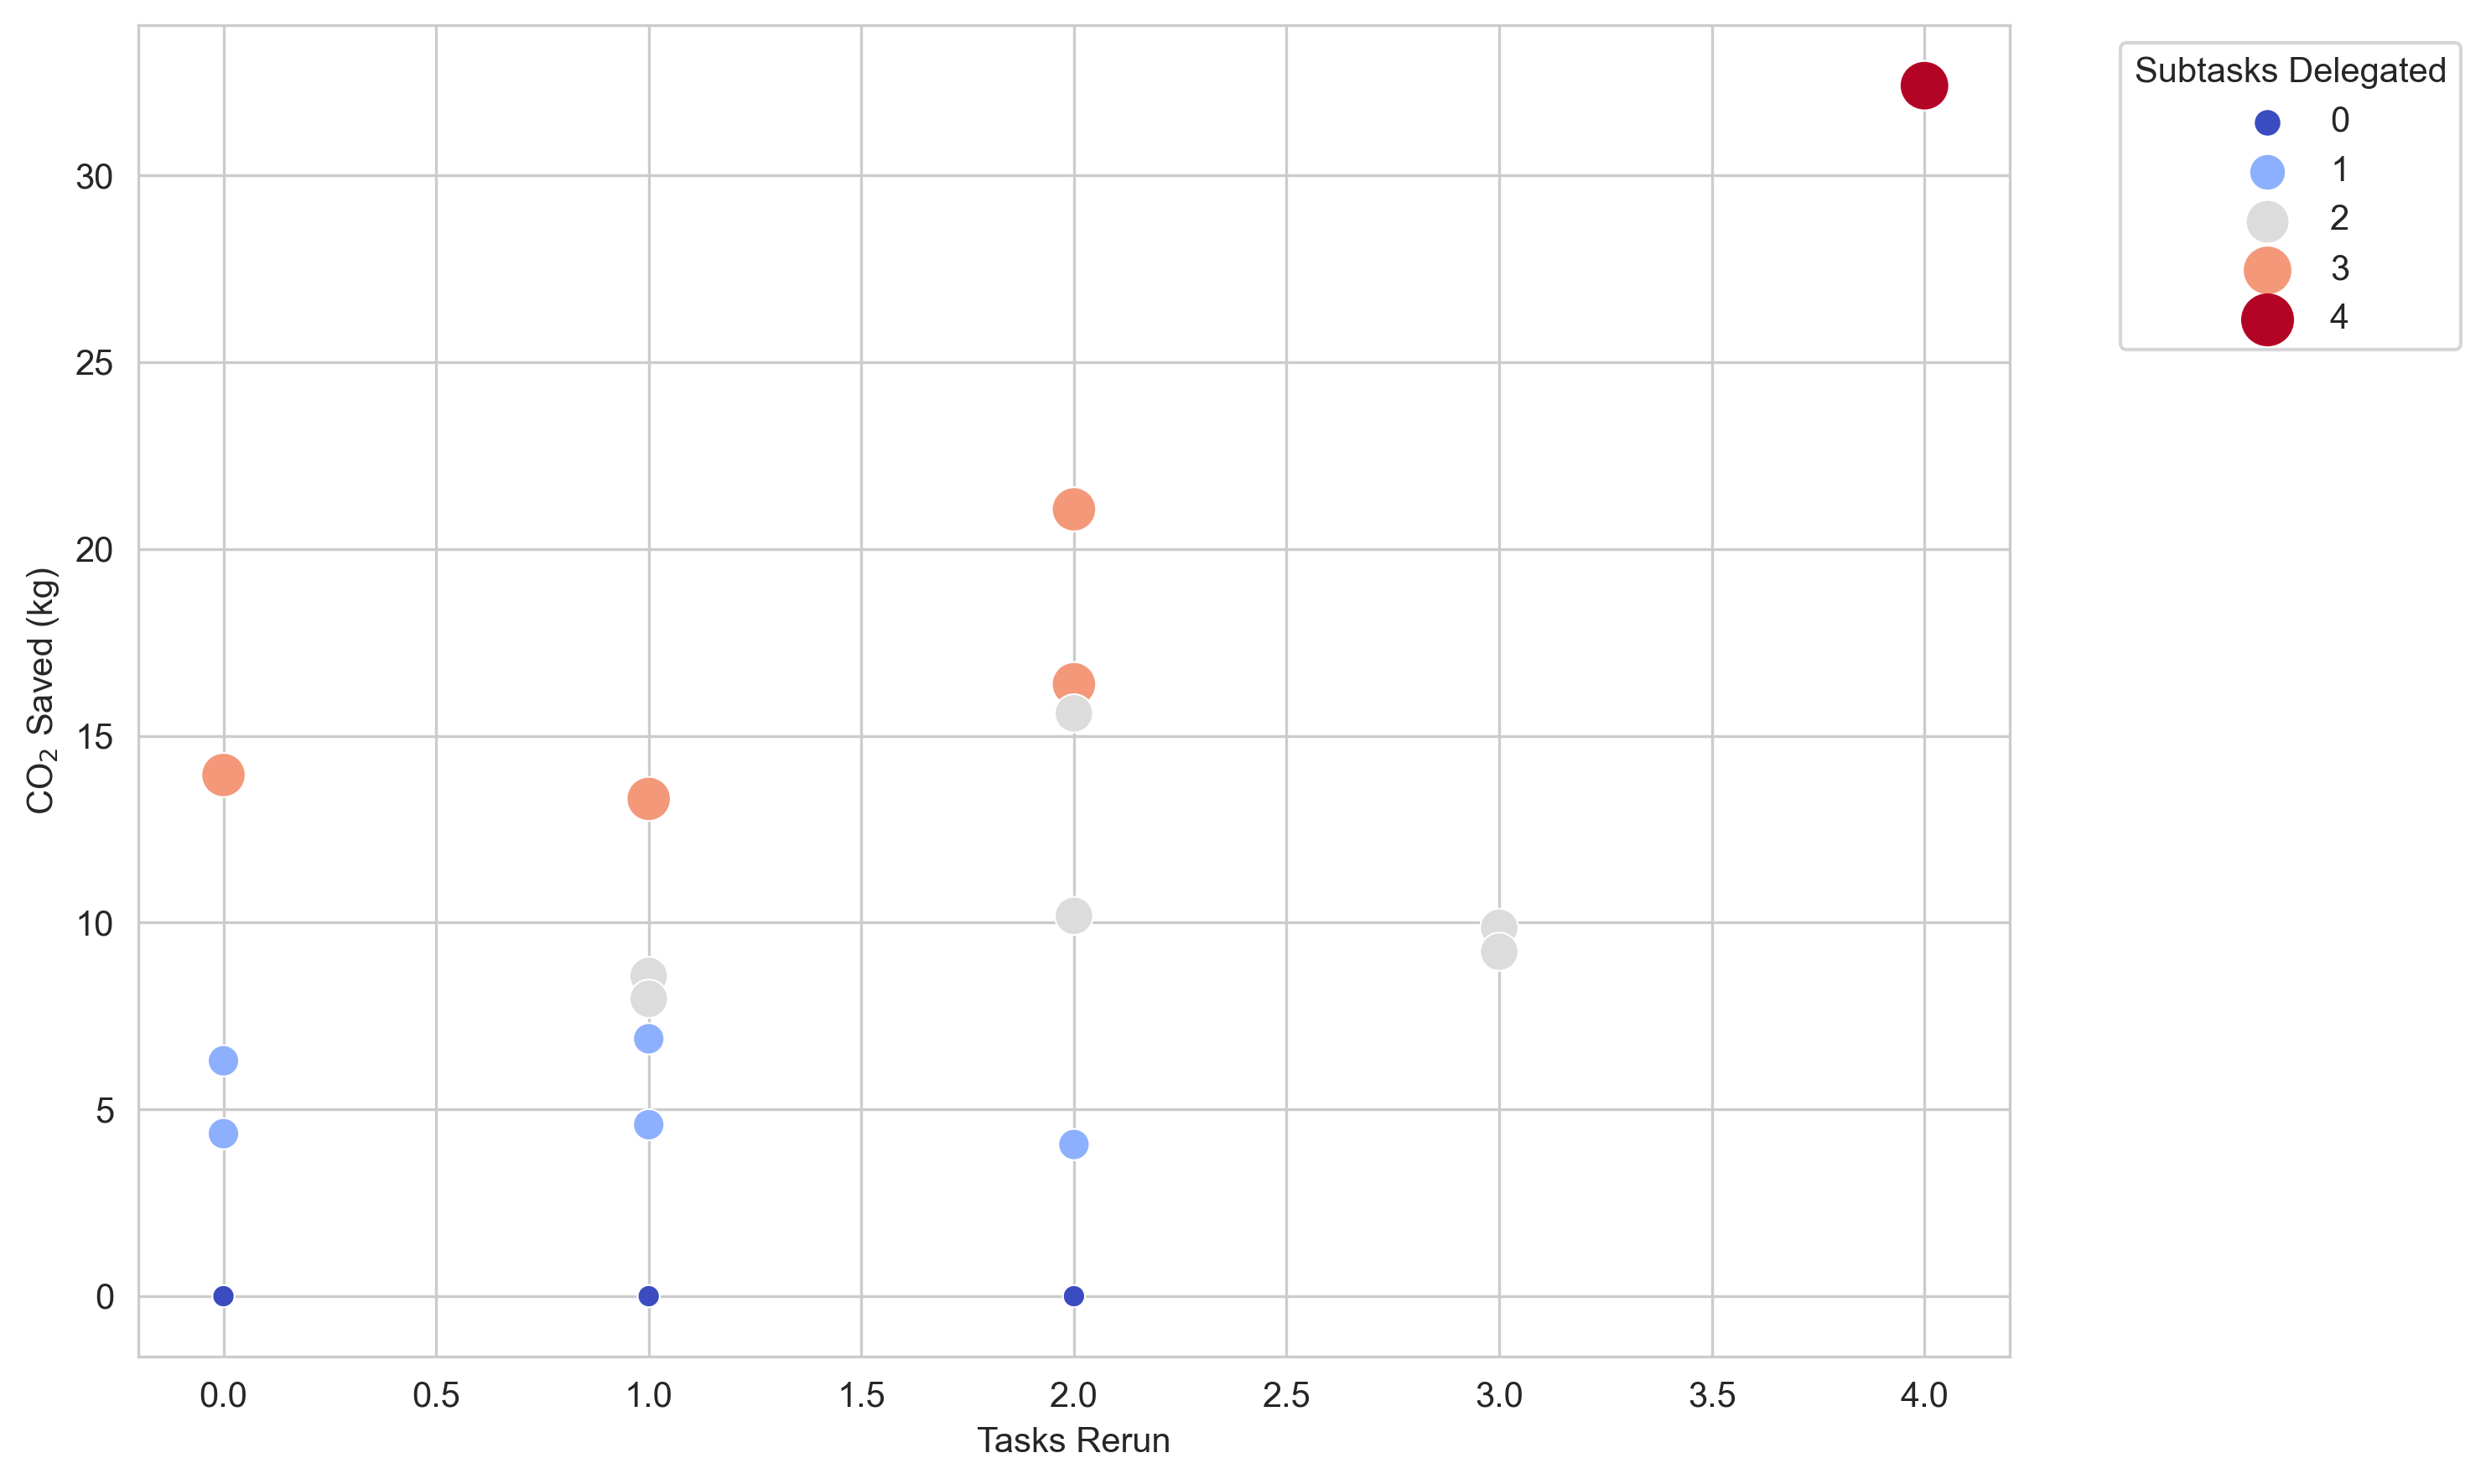

/var/folders/v6/43nstwv52771z0q7sjpfqzv00000gn/T/ipykernel_58522/1423788162.py:18: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from current font.
  plt.tight_layout()
/Users/kayadetunji/anaconda3/envs/kaymacmini/lib/python3.9/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


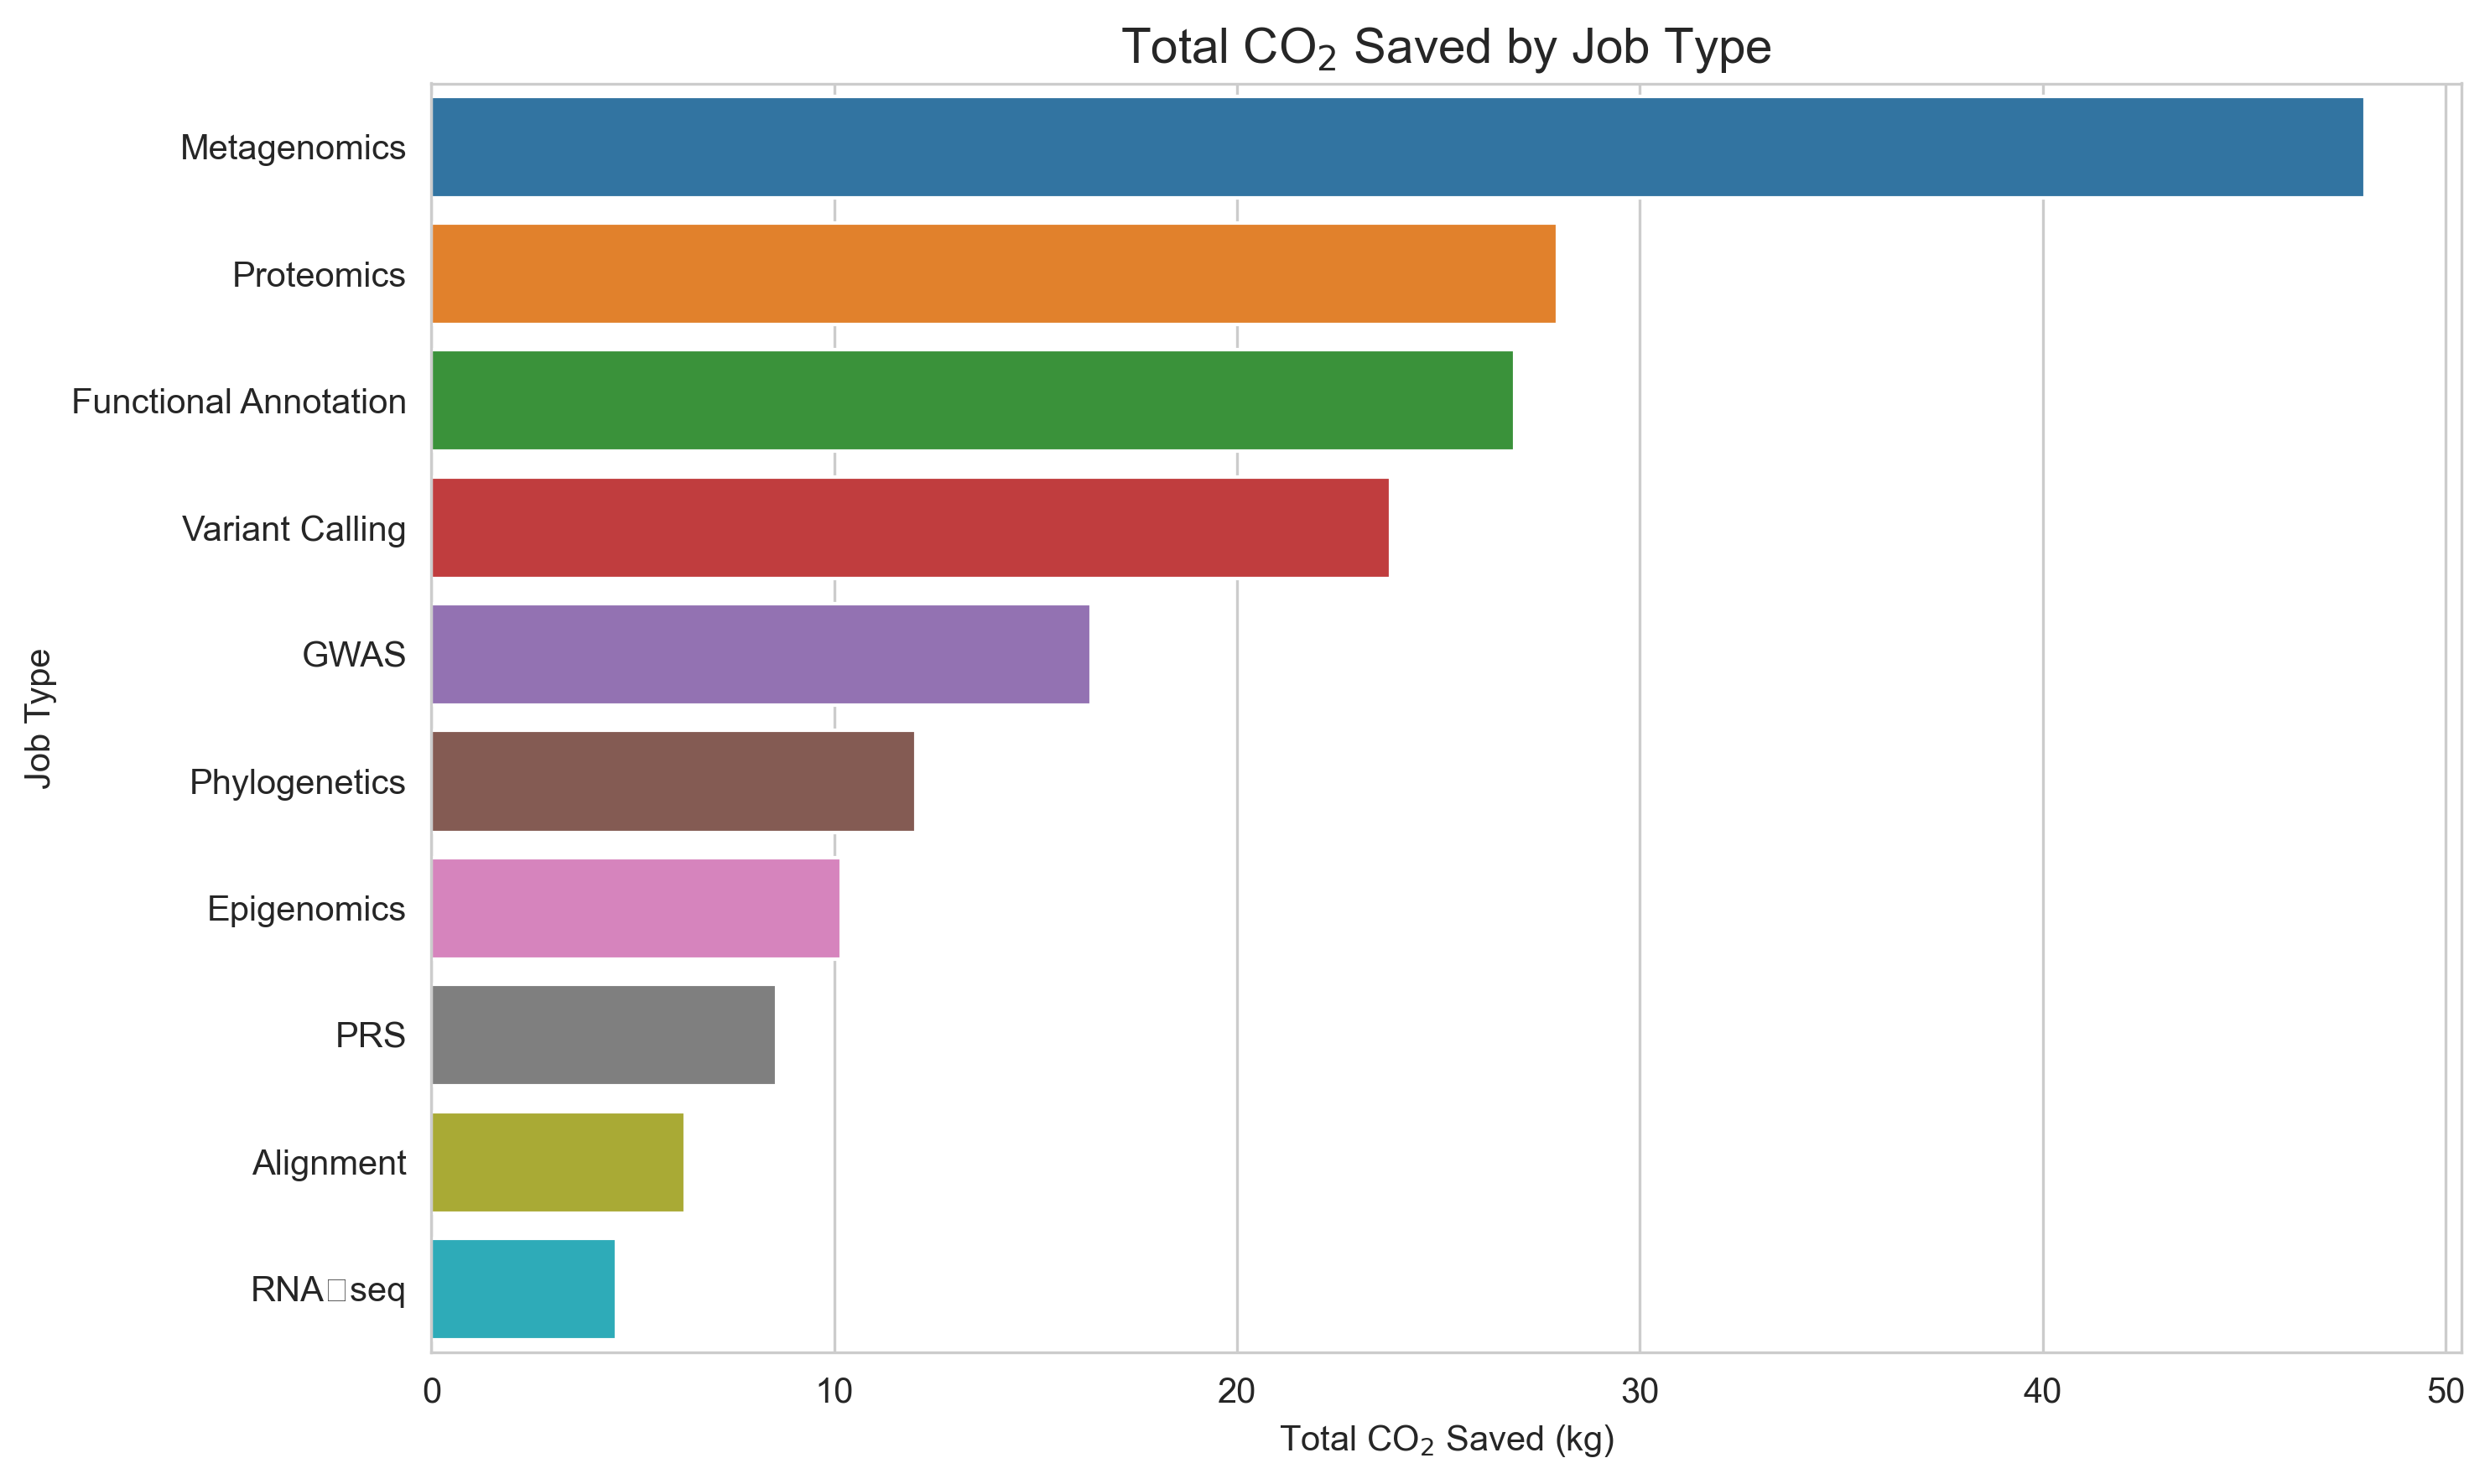

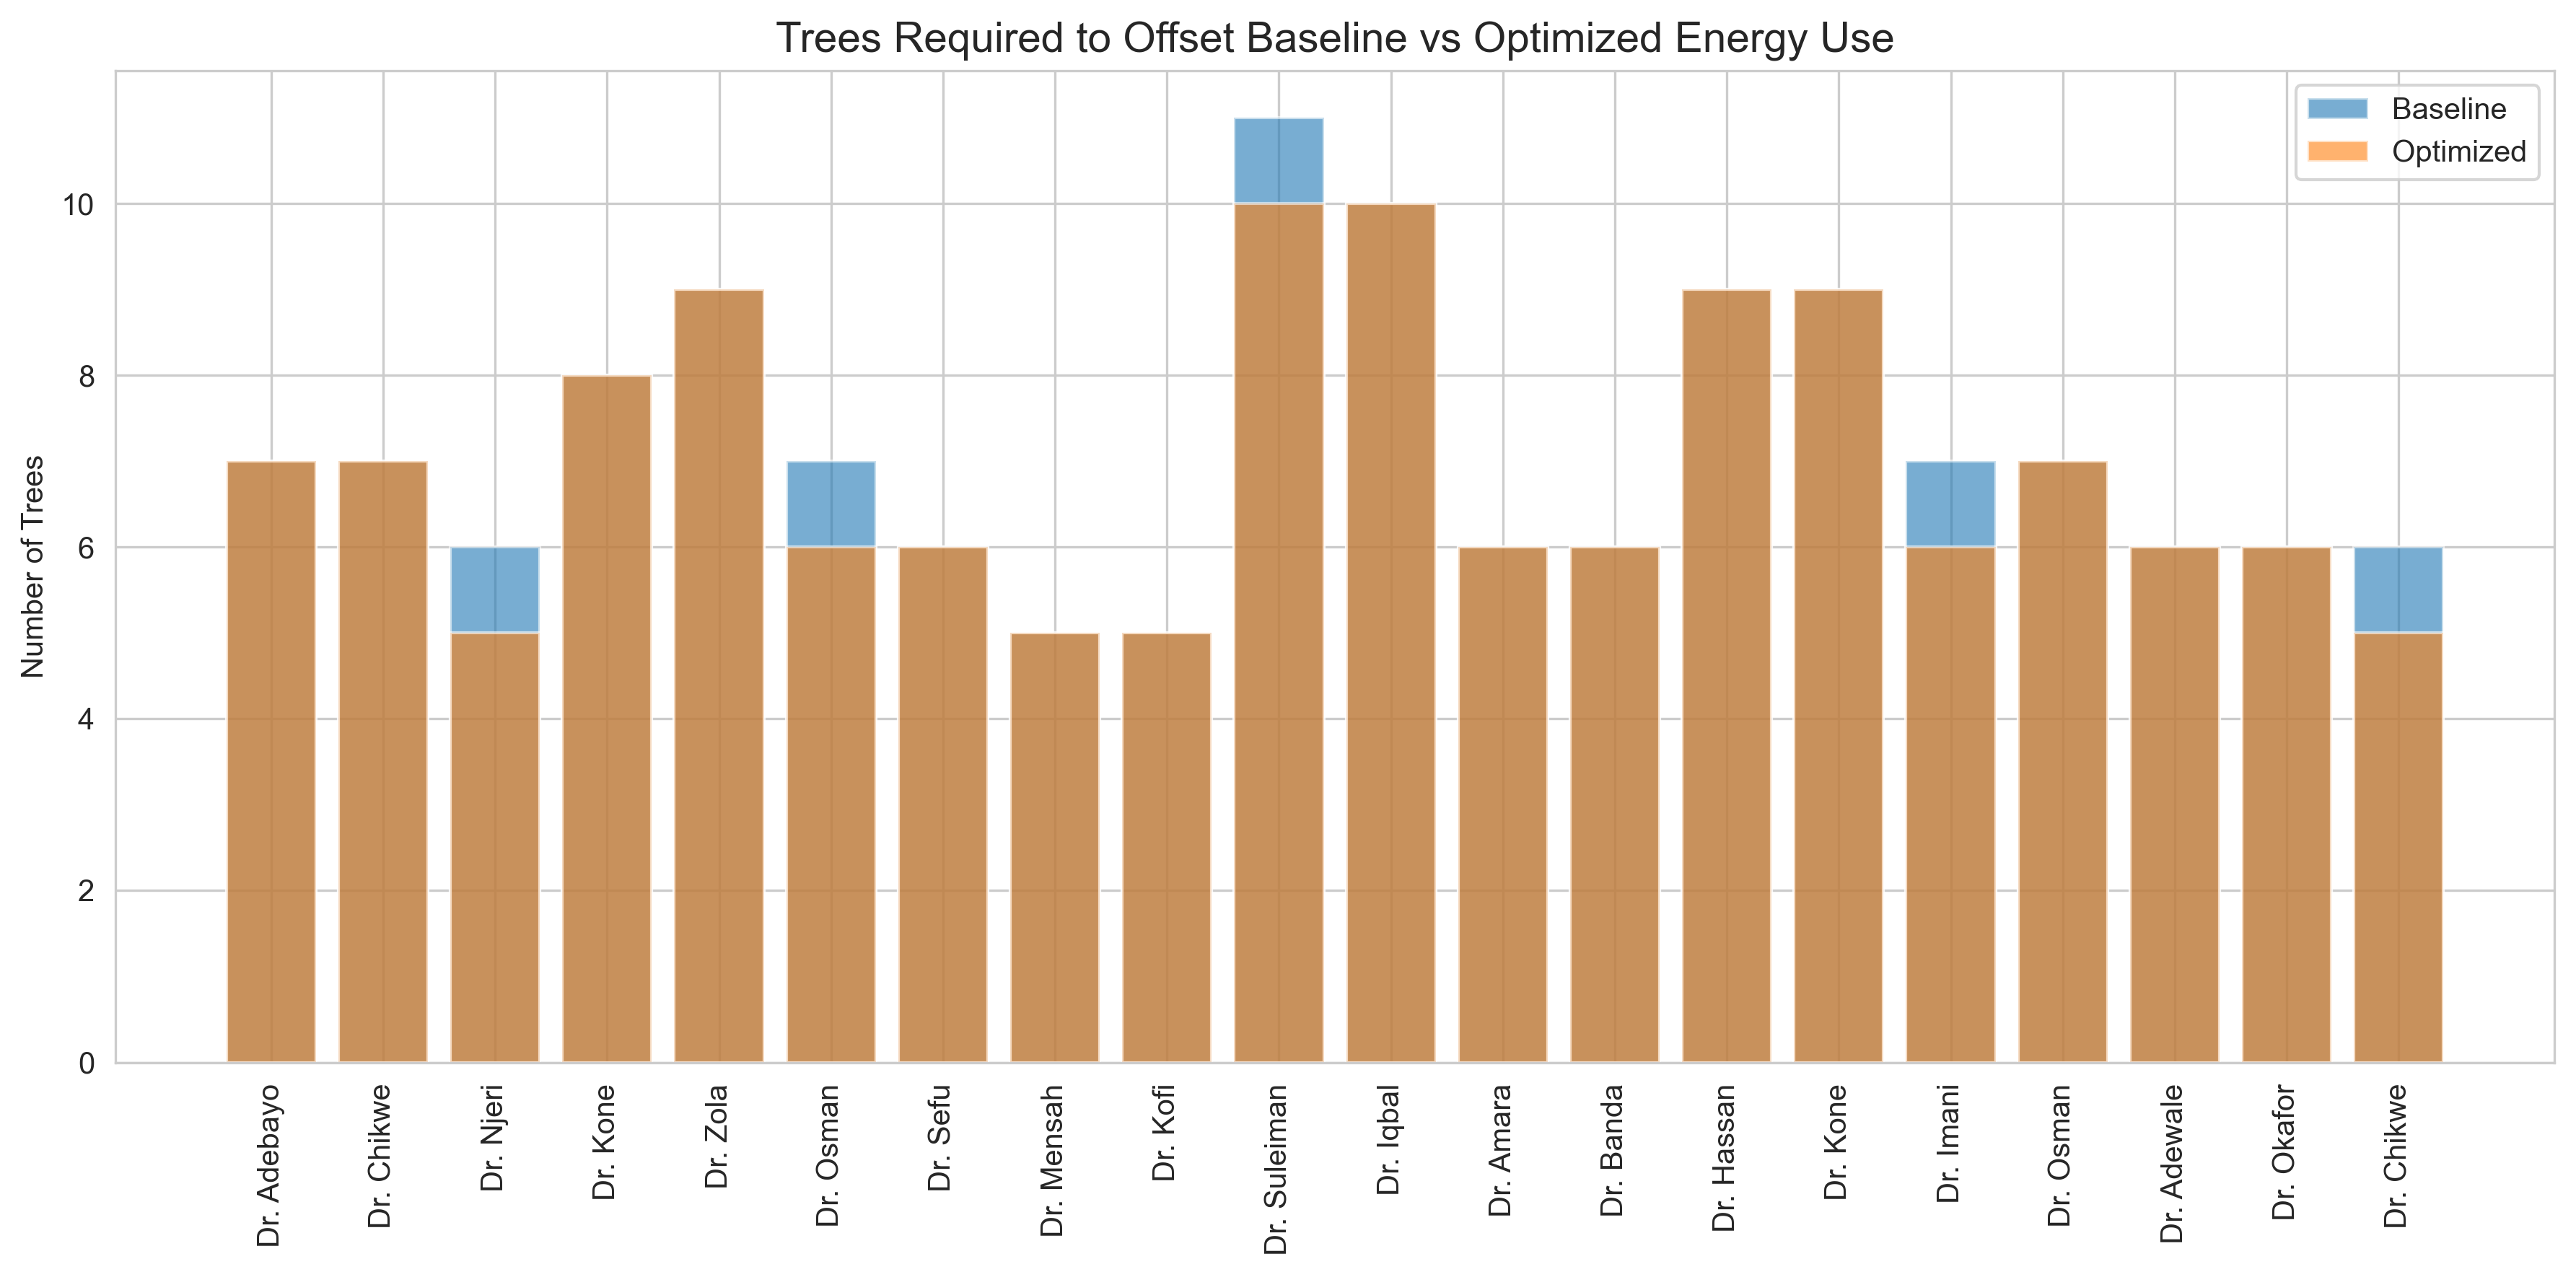

In [33]:
# 1. Delegation & Reruns vs. CO2 Saved
plt.figure(figsize=(10, 6), dpi=300)
sns.scatterplot(data=df, x="Tasks Rerun", y="CO2 Saved (kg)", hue="Subtasks Delegated", size="Subtasks Delegated", palette="coolwarm", sizes=(40, 200))
# plt.title("CO₂ Saved vs Tasks Rerun (Color/Size = Subtasks Delegated)")
plt.xlabel("Tasks Rerun")
plt.ylabel("CO$_2$ Saved (kg)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Subtasks Delegated')
plt.tight_layout()
plt.show()

# 2. CO2 Saved per Job Type
plt.figure(figsize=(10, 6), dpi=300)
jobtype_savings = df.groupby("Job Type")["CO2 Saved (kg)"].sum().sort_values(ascending=False)
sns.barplot(x=jobtype_savings.values, y=jobtype_savings.index)
plt.title("Total CO$_2$ Saved by Job Type")
plt.xlabel("Total CO$_2$ Saved (kg)")
plt.ylabel("Job Type")
plt.tight_layout()
plt.show()

# 3. Tree Offset Comparison: Baseline vs Optimized
plt.figure(figsize=(12, 6), dpi=300)
x = range(len(df))
plt.bar(x, df["Trees to Offset Baseline"], label="Baseline", alpha=0.6)
plt.bar(x, df["Trees to Offset Optimized"], label="Optimized", alpha=0.6)
plt.xticks(x, df["Researcher"], rotation=90)
plt.ylabel("Number of Trees")
plt.title("Trees Required to Offset Baseline vs Optimized Energy Use")
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
features = df[["Tasks Rerun", "Subtasks Delegated", "Runtime Increase (%)"]]
target = df["CO2 Saved (kg)"]
features = sm.add_constant(features)
model = sm.OLS(target, features).fit()

# Summary table of regression model
summary_table = model.params.rename("Coefficient").to_frame()
summary_table["Description"] = [
    "Intercept",
    "Each additional task rerun",
    "Each additional subtask delegated",
    "Each 1% increase in runtime"
]
summary_table.reset_index(inplace=True)
summary_table.rename(columns={"index": "Variable"}, inplace=True)

In [17]:
summary_table

,Variable,Coefficient,Description
0,const,-2.214753,Intercept
1,Tasks Rerun,1.335830,Each additional task rerun
2,Subtasks Delegated,0.221720,Each additional subtask delegated
3,Runtime Increase (%),1.108601,Each 1% increase in runtime


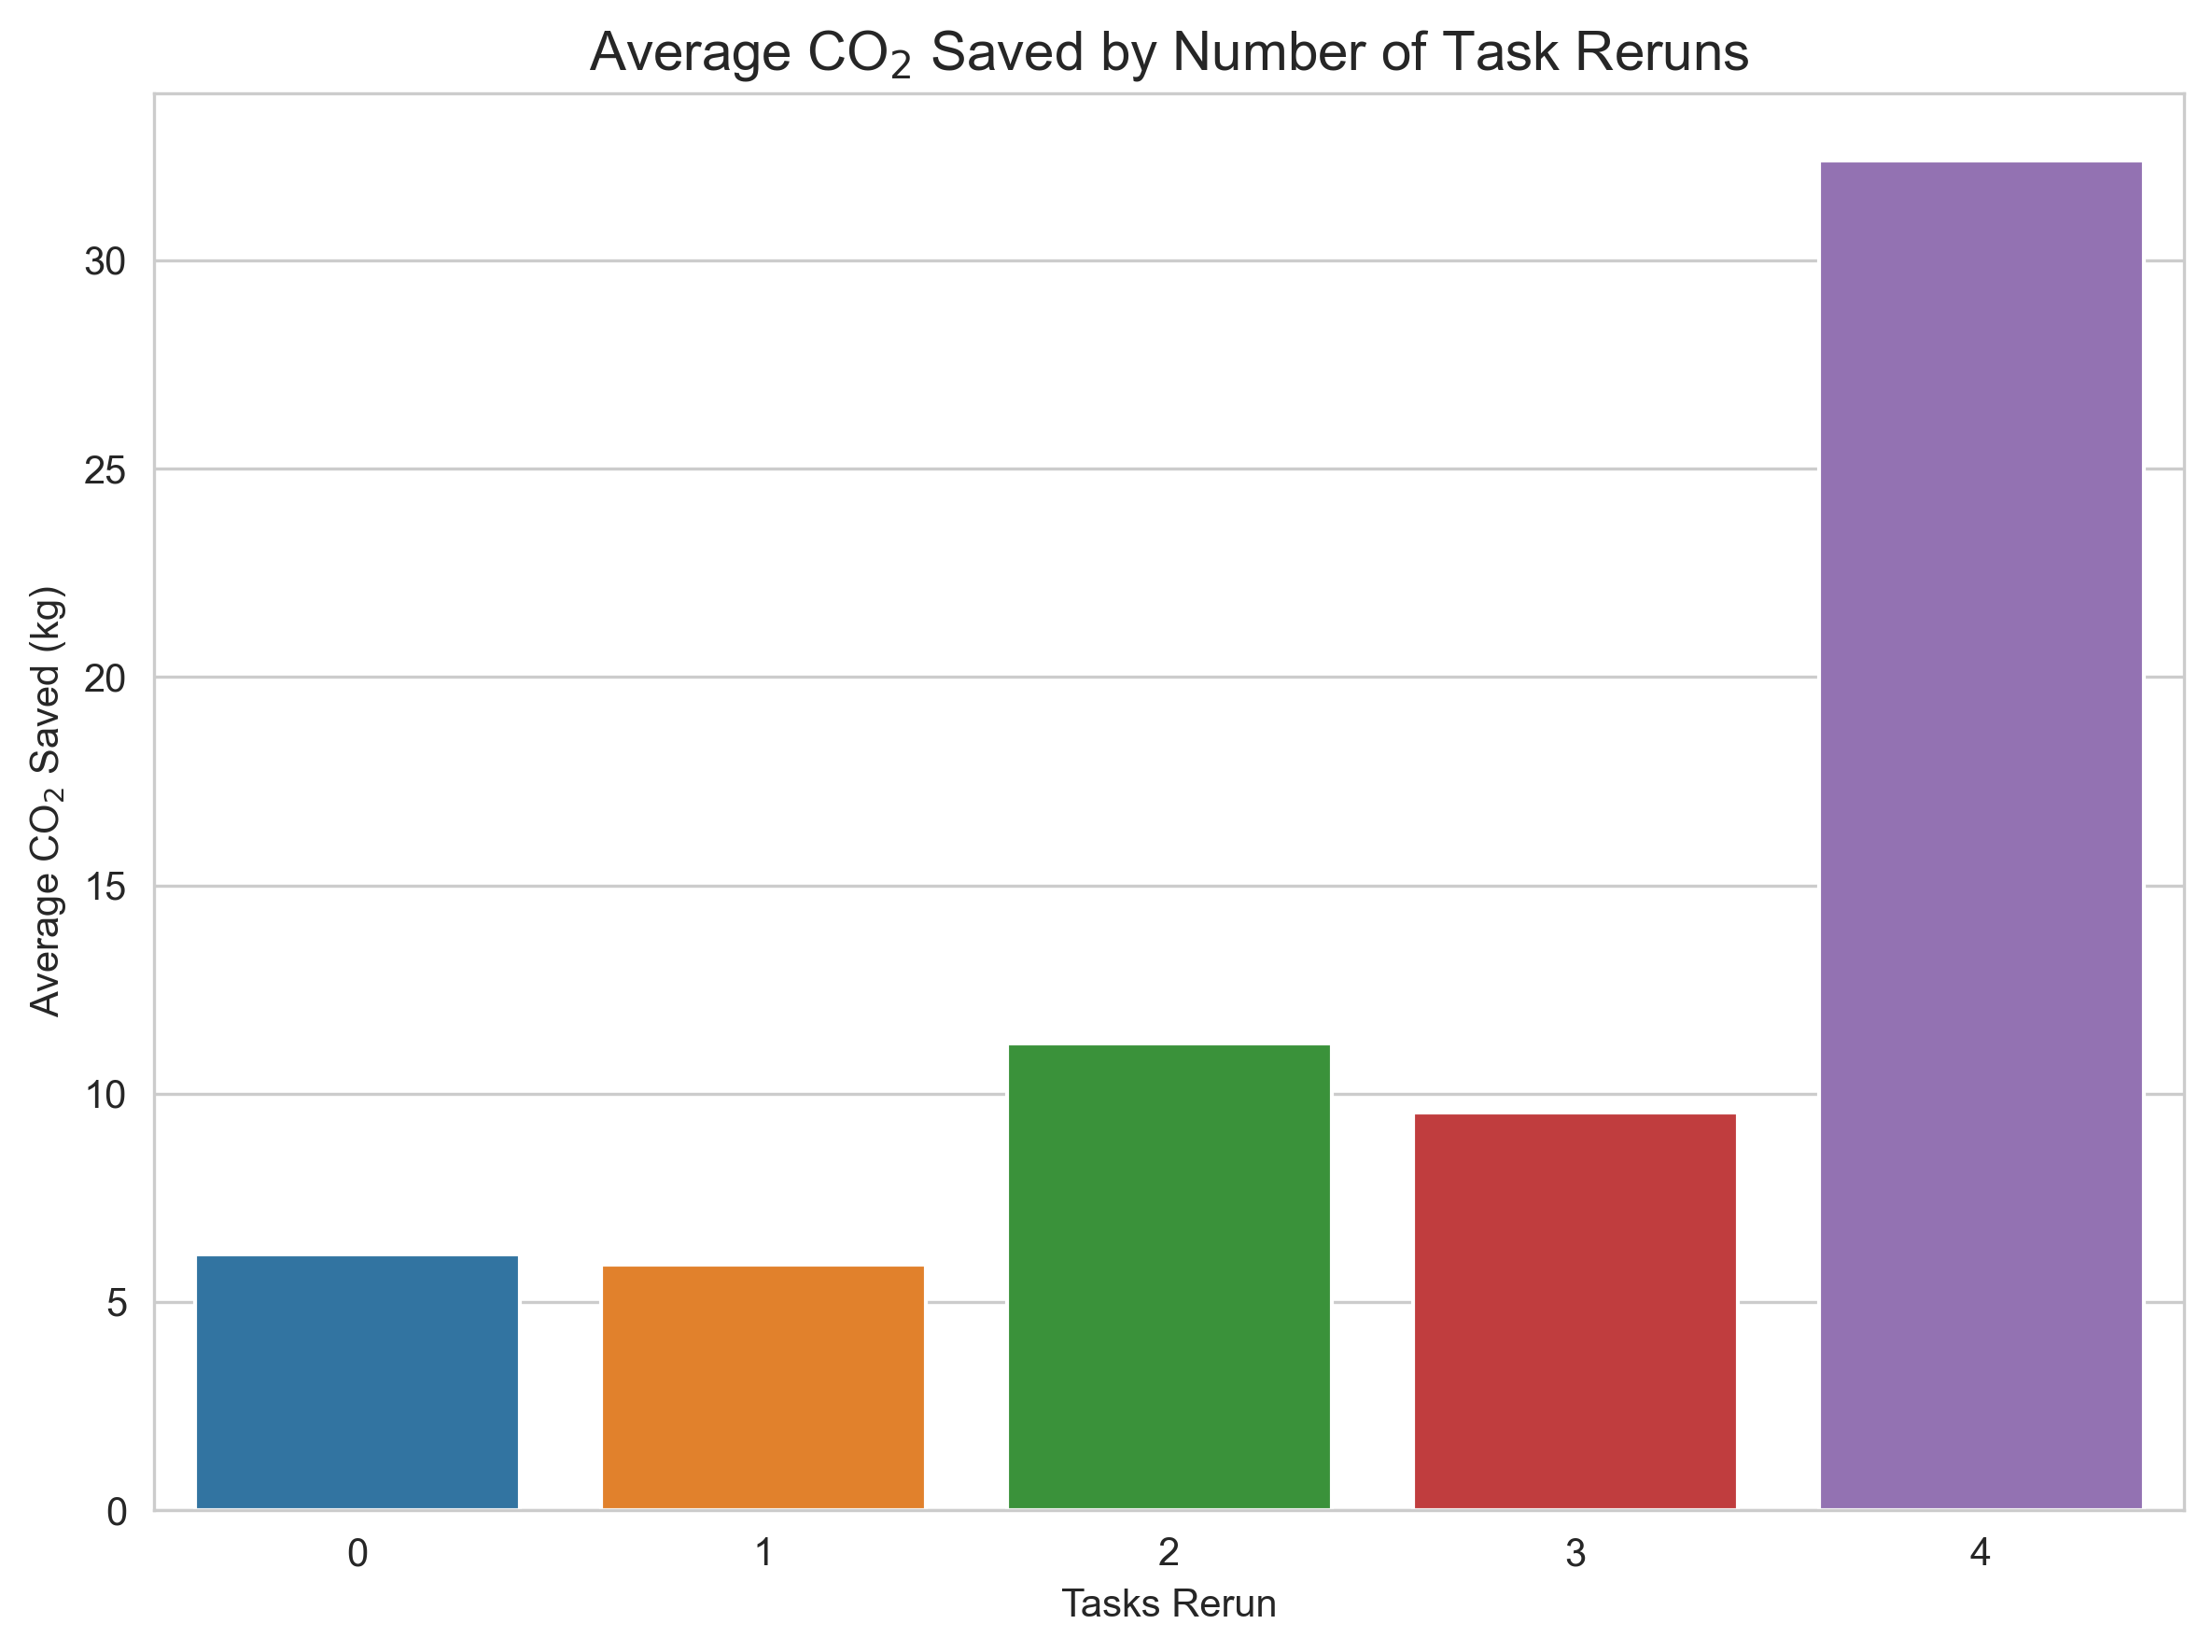

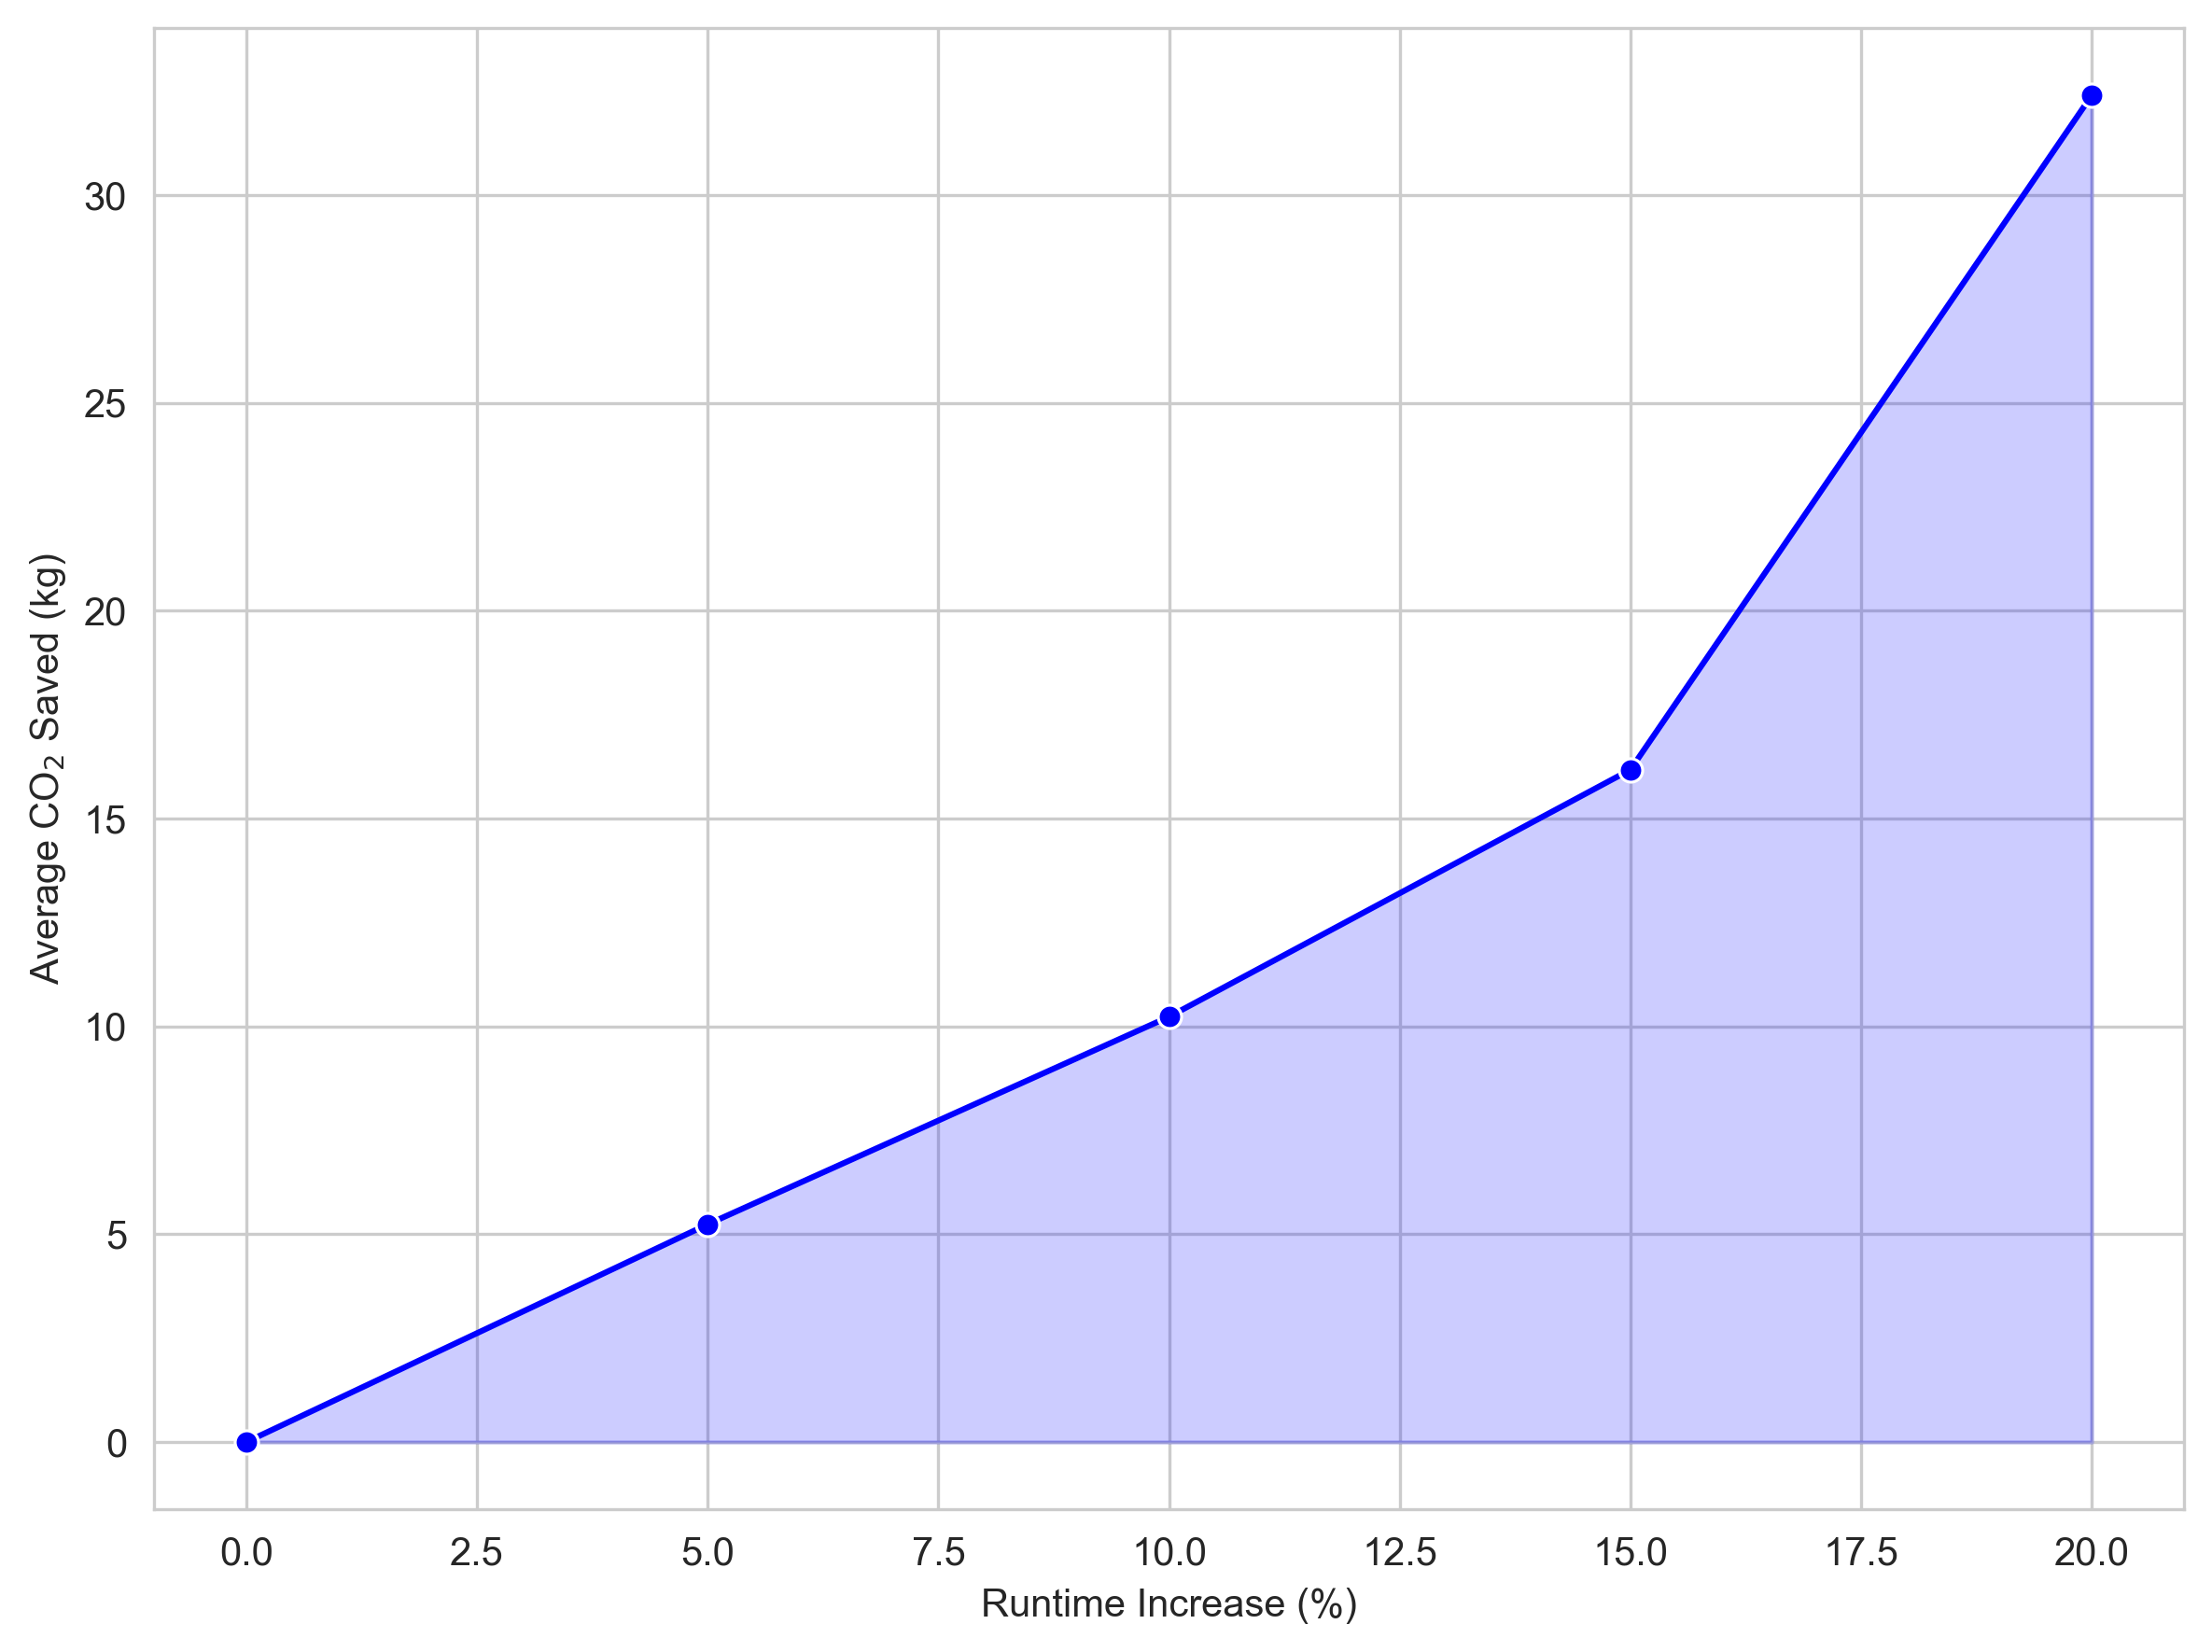

/var/folders/v6/43nstwv52771z0q7sjpfqzv00000gn/T/ipykernel_58522/1760534226.py:29: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from current font.
  plt.tight_layout()
/Users/kayadetunji/anaconda3/envs/kaymacmini/lib/python3.9/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


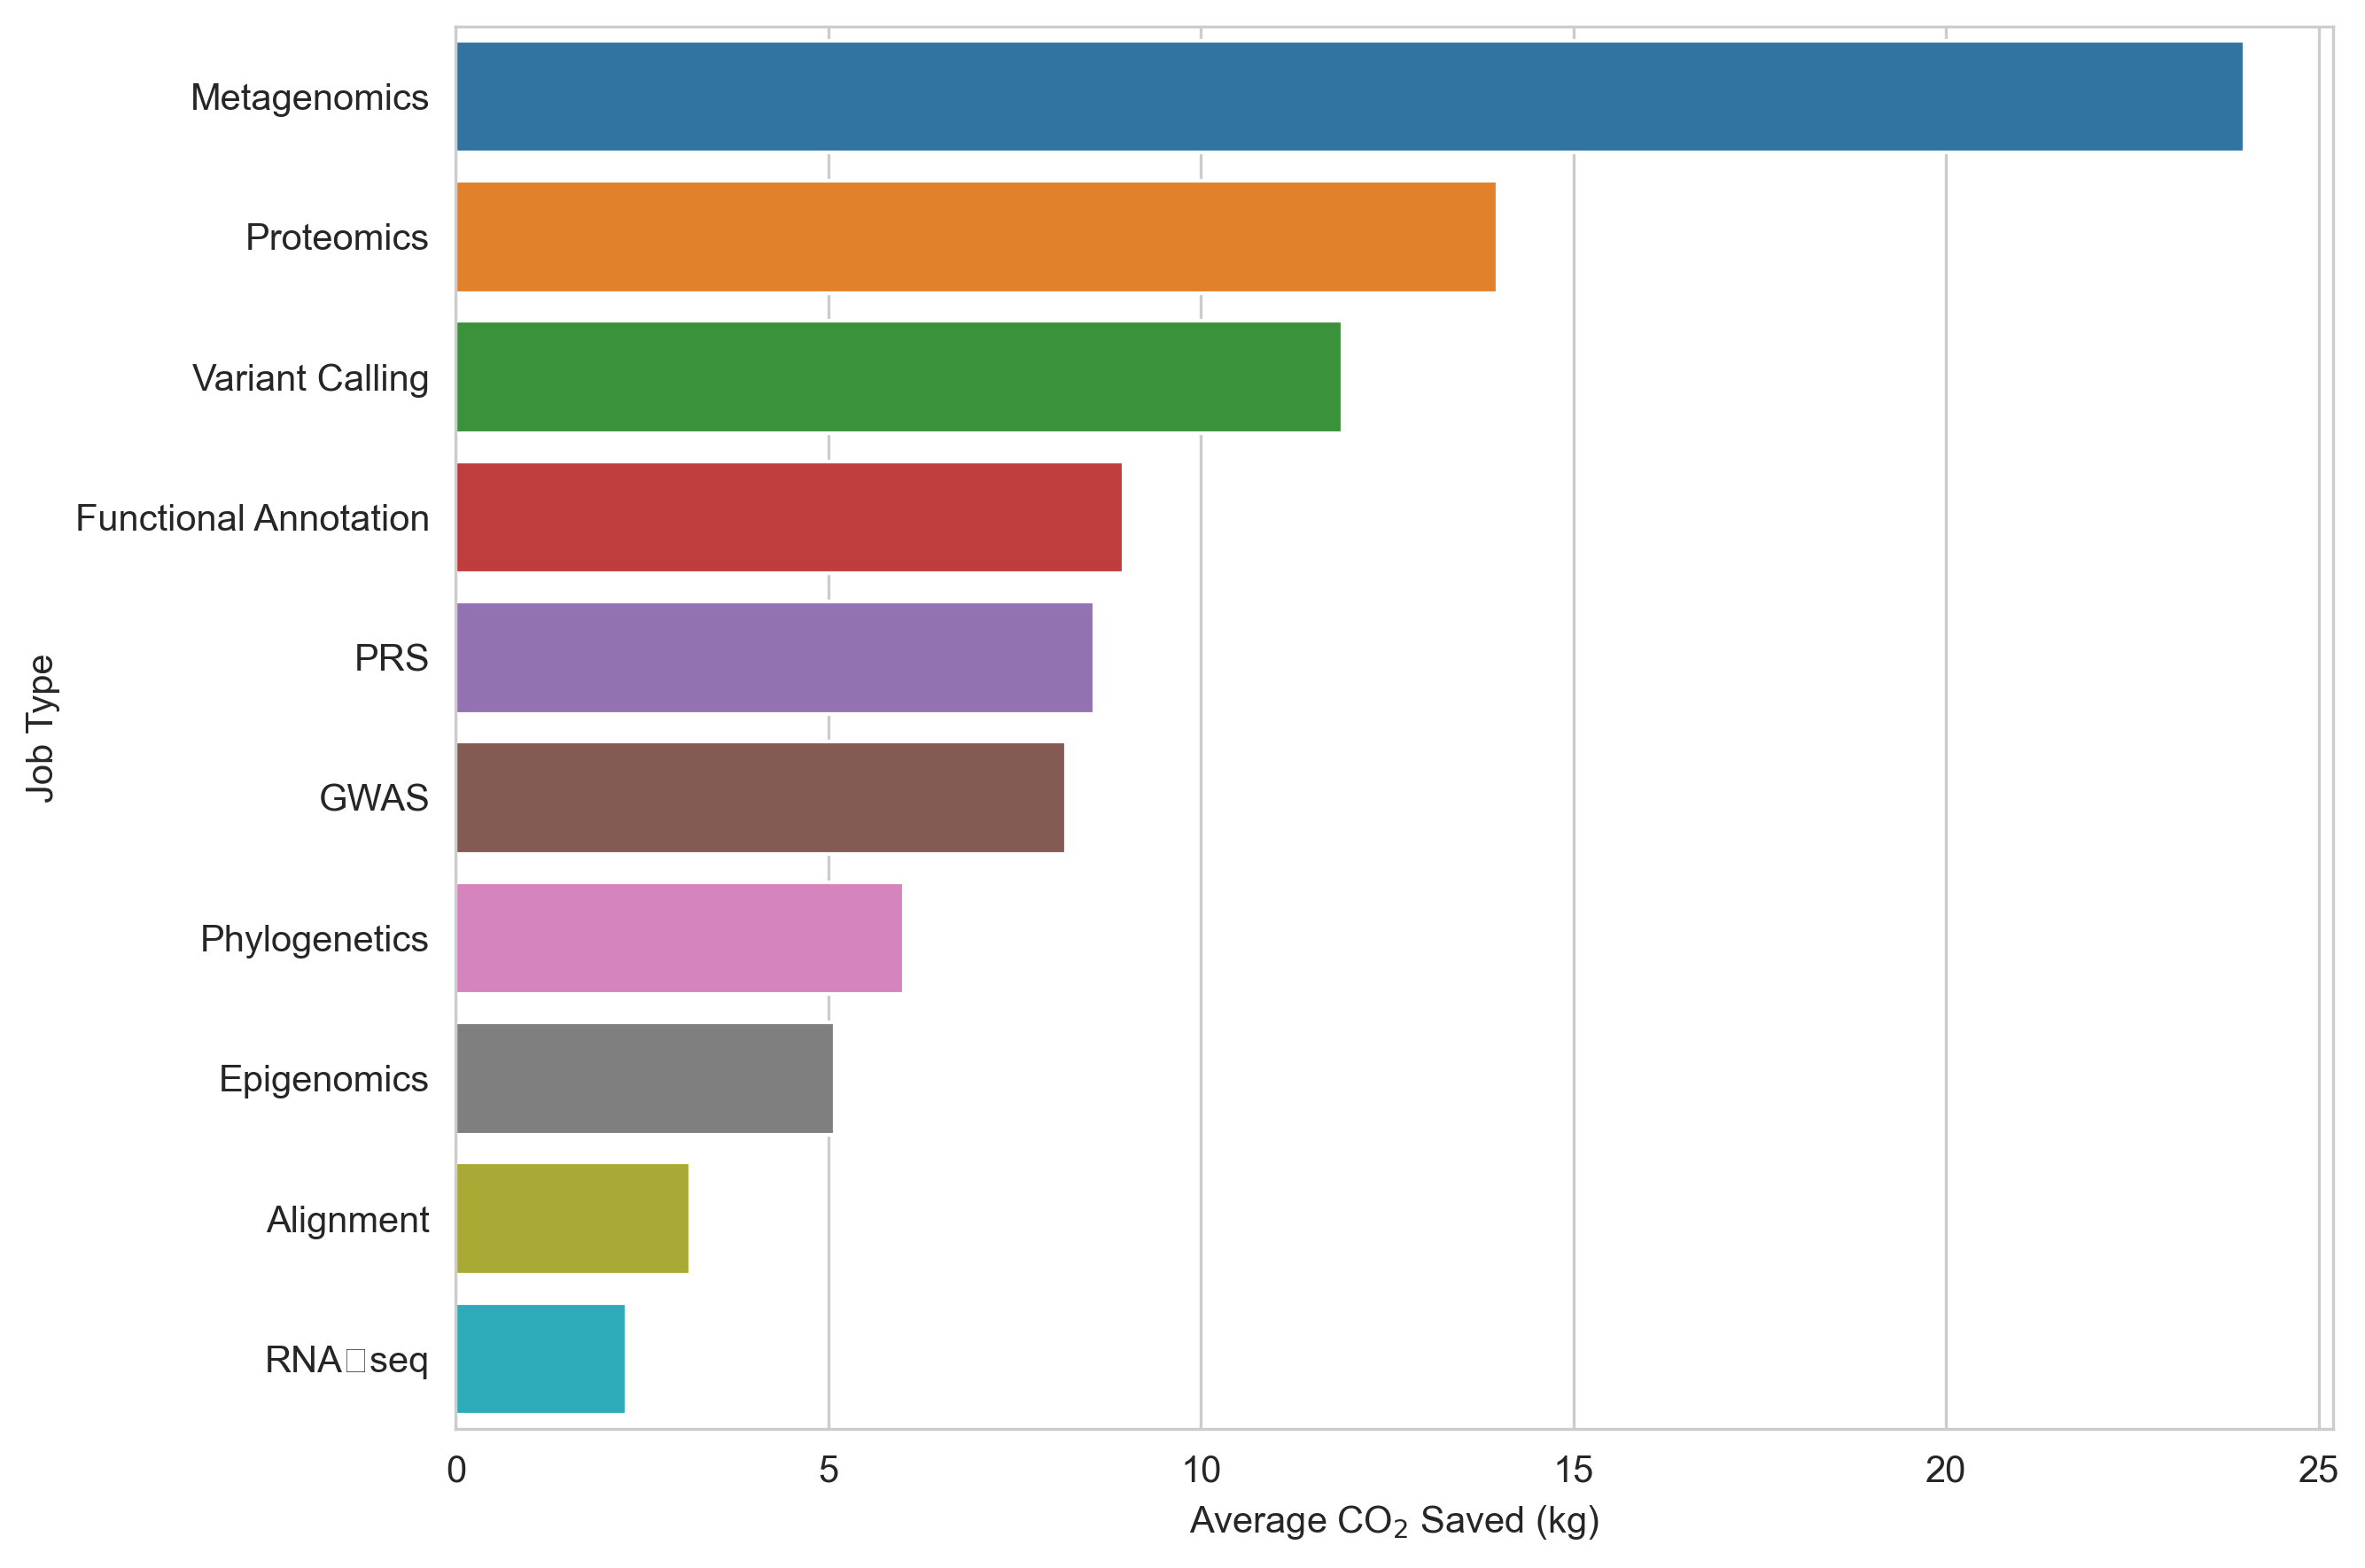

In [32]:
# 1. CO2 Saved by Task Reruns
plt.figure(figsize=(8, 6), dpi=300)
rerun_group = df.groupby("Tasks Rerun")["CO2 Saved (kg)"].mean().reset_index()
sns.barplot(data=rerun_group, x="Tasks Rerun", y="CO2 Saved (kg)")
plt.title("Average CO$_2$ Saved by Number of Task Reruns")
plt.ylabel("Average CO$_2$ Saved (kg)")
plt.xlabel("Tasks Rerun")
plt.tight_layout()
plt.show()

# 2. CO2 Saved vs Runtime Increase
plt.figure(figsize=(8, 6), dpi=300)
runtime_group = df.groupby("Runtime Increase (%)")["CO2 Saved (kg)"].mean().reset_index()
sns.lineplot(data=runtime_group, x="Runtime Increase (%)", y="CO2 Saved (kg)", marker="o", color="blue")
plt.fill_between(runtime_group["Runtime Increase (%)"], runtime_group["CO2 Saved (kg)"], alpha=0.2, color="blue")
# plt.title("CO$_2$ Saved vs Runtime Increase")
plt.ylabel("Average CO$_2$ Saved (kg)")
plt.xlabel("Runtime Increase (%)")
plt.tight_layout()
plt.show()

# 3. Average CO2 Saved by Job Type
plt.figure(figsize=(9, 6), dpi=300)
job_group = df.groupby("Job Type")["CO2 Saved (kg)"].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=job_group, y="Job Type", x="CO2 Saved (kg)")
# plt.title("Average CO$_2$ Saved by Workflow Type")
plt.xlabel("Average CO$_2$ Saved (kg)")
plt.ylabel("Job Type")
plt.tight_layout()
plt.show()